<center><font size=6> Bank Churn Prediction </font></center>

## Problem Statement

### Context

Businesses like banks which provide service have to worry about problem of 'Customer Churn' i.e. customers leaving and joining another service provider. It is important to understand which aspects of the service influence a customer's decision in this regard. Management can concentrate efforts on improvement of service, keeping in mind these priorities.

### Objective

You as a Data scientist with the  bank need to  build a neural network based classifier that can determine whether a customer will leave the bank  or not in the next 6 months.

### Data Dictionary

* CustomerId: Unique ID which is assigned to each customer

* Surname: Last name of the customer

* CreditScore: It defines the credit history of the customer.
  
* Geography: A customer’s location
   
* Gender: It defines the Gender of the customer
   
* Age: Age of the customer
    
* Tenure: Number of years for which the customer has been with the bank

* NumOfProducts: refers to the number of products that a customer has purchased through the bank.

* Balance: Account balance

* HasCrCard: It is a categorical variable which decides whether the customer has credit card or not.

* EstimatedSalary: Estimated salary

* isActiveMember: Is is a categorical variable which decides whether the customer is active member of the bank or not ( Active member in the sense, using bank products regularly, making transactions etc )

* Exited : whether or not the customer left the bank within six month. It can take two values
** 0=No ( Customer did not leave the bank )
** 1=Yes ( Customer left the bank )

## Helper Functions
All helper functions implemented here can be moved to a separate file and imported to improve code clarity and organization.


In [10]:
def print_header(text, level=2):
    """
    Display a header in Markdown format.

    This function generates and displays a header using Markdown formatting, 
    with a customizable header level.

    Parameters:
        text (str): The header text to be displayed.
        level (int, optional): The Markdown header level. Defaults to 2.
                               For example, level=2 will generate a header 
                               formatted as '## Header Text'.
    
    Returns:
        None
    """
    display(Markdown(f"{'#' * level} {text}"))

def table_styler_and_display(df, title='', level=3):
    """
    Style and display a DataFrame as an HTML table with a custom appearance.

    This function applies custom styles to a Pandas DataFrame using the `style` 
    property and displays the styled table. It also prints a header for the table 
    using Markdown.

    Parameters:
        df (pandas.DataFrame): The DataFrame to be styled and displayed.
        title (str, optional): The title to be displayed above the table. Defaults to an empty string.
        level (int, optional): The Markdown header level for the title. Defaults to 3.
                               For example, level=3 will generate a header formatted 
                               as '### Title'.
    
    Returns:
        None
    """
    styled_table = df.style.set_properties(**{
        'background-color': '#f8f9fa',
        'border': '1px solid #dee2e6',
        'padding': '8px'
    }).set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#343a40'), ('color', 'white')]
    }])
    print_header(title, level)
    display(styled_table)

## Importing necessary libraries

In [12]:
# Import numerical computing library for array operations and mathematical functions
import numpy as np

# Import data manipulation and analysis library for working with DataFrames
import pandas as pd

# Import plotting library for creating static, animated, and interactive visualizations
import matplotlib.pyplot as plt

# Import statistical data visualization library built on top of matplotlib
import seaborn as sns

# Import function for splitting datasets into training and testing sets
from sklearn.model_selection import train_test_split

# Import class for standardizing features by removing mean and scaling to unit variance
from sklearn.preprocessing import StandardScaler

# Import deep learning framework for building neural networks
import tensorflow as tf

# Import modules for creating sequential neural network models and layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

# Import backend module for clearing session and managing TensorFlow resources
from tensorflow.keras import backend

# Import library for generating random numbers and random operations
import random

# Import functions for enhanced output display in Jupyter Notebook
from IPython.display import display, HTML, Markdown

# Import SMOTE for oversampling minority classes in imbalanced datasets
from imblearn.over_sampling import SMOTE

# Import warnings module to control warning messages
import warnings

# Suppress warning messages for cleaner output during code execution
warnings.filterwarnings("ignore")

## Loading the dataset

In [14]:
# Read bank churn data from CSV file into a pandas DataFrame
bank_churn = pd.read_csv('bank-1.csv')

# Create a copy of the original DataFrame to preserve the source data
df = bank_churn.copy()

## Data Overview

In [16]:
# Get the shape of the DataFrame, which returns a tuple (number of rows, number of columns)
print(f'Dataset has {df.shape[1]} features and {df.shape[0]} data row')

Dataset has 14 features and 10000 data row


In [17]:
# Display the first 5 rows of the DataFrame to preview the data
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [18]:
# Generate summary statistics for each column in the DataFrame and transpose the result for better readability
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


**Variable Insights:**

- RowNumber: Seems to be a unique identifier for each row (like an index). Not likely to be a useful feature for modeling.
- CustomerId: Likely another unique identifier. Again, not likely useful for modeling in its raw form.
- CreditScore: Ranges from 350 to 850, with a mean of 650.5. This is a potentially important feature for credit risk assessment or related tasks.
- Age: Ranges from 18 to 92, with a mean of 38.9. A plausible age distribution.
- Tenure: Represents how long the customer has been with the bank (in years). Ranges from 0 to 10, with a mean of 5.0. Suggests a fairly even distribution of tenures.
- Balance: Ranges from 0 to 250,898.09, with a mean of 76,485.89. A large standard deviation indicates a wide range of balances, suggesting some customers have significantly higher balances than others.
- NumOfProducts: Indicates the number of bank products the customer uses. Ranges from 1 to 4, with a mean of 1.53. Most customers seem to use 1 or 2 products.
- HasCrCard: A binary variable (0 or 1) indicating whether the customer has a credit card. 70.55% of customers have a credit card.
- IsActiveMember: A binary variable (0 or 1) indicating whether the customer is an active member. 51.51% of customers are active members.
- EstimatedSalary: Ranges from 11.58 to 199,992.48, with a mean of 100,090.20. A high standard deviation suggests a wide range of salaries.
- Exited: A binary variable (0 or 1) indicating whether the customer has left the bank. 20.37% of customers have exited. This is likely the target variable for a churn prediction model.

In [20]:
# Remove unnecessary identifier columns from the DataFrame
# 'RowNumber', 'CustomerId', and 'Surname' are dropped as they typically don't contribute to churn prediction
# axis=1 specifies column-wise operation, inplace=True modifies df directly
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [21]:
# Display a concise summary of the DataFrame including column names, non-null counts, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


**Column Details:**

- Column: The name of the variable (e.g., CreditScore, Geography, Age).
- Non-Null Count: The number of non-missing (valid) values in that column. In my case, it's 10000 for all columns, meaning there are no missing values. This is great for analysis, as you don't need to worry about imputation or handling missing data for now.
- Dtype: The data type of the column:
    - int64: Integer numbers (e.g., CreditScore, Age, Tenure, NumOfProducts, HasCrCard, IsActiveMember, Exited).
    - float64: Floating-point numbers (e.g., Balance, EstimatedSalary).
    - object: Typically strings or a mix of data types (e.g., Geography, Gender).



In [23]:
# Count the number of duplicated rows in the DataFrame
print(f'The dataset has {df.duplicated().sum()} duplicate rows')

The dataset has 0 duplicate rows


In [24]:
# Calculate the number of missing values in each column of the DataFrame
missing_values_count = df.isna().sum()

# Convert the Series to a DataFrame and rename the column for better readability
missing_values_df = missing_values_count.to_frame(name='Missing Values')

# Display the missing values using a custom table styling function
table_styler_and_display(missing_values_df, "Null Value Counter")

### Null Value Counter

,Missing Values
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [25]:
# Print the unique values for the 'Geography' column.
# This helps understand the categories present in this categorical feature.
print('The unique values for Geography: ', df['Geography'].unique())

# Print the unique values for the 'Gender' column.
# Similar to Geography, this shows the different gender categories in the dataset.
print('The unique values for Gender: ', df['Gender'].unique())

# Print the unique values for the 'NumOfProducts' column.
# This reveals the distinct number of products offered by the bank that customers can have.
print('The unique values for NumOfProducts: ', df['NumOfProducts'].unique())

The unique values for Geography:  ['France' 'Spain' 'Germany']
The unique values for Gender:  ['Female' 'Male']
The unique values for NumOfProducts:  [1 3 2 4]


### Outlier Percentage Calculation and Display

In [27]:
# Select numeric columns from the DataFrame for outlier analysis
num_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate the first quartile (Q1) and third quartile (Q3) for each numeric column
Q1 = num_df.quantile(0.25)
Q3 = num_df.quantile(0.75)

# Compute the interquartile range (IQR) as the difference between Q3 and Q1
IQR = Q3 - Q1

# Define the boundaries for outliers (1.5 times the IQR below Q1 and above Q3)
low_border = Q1 - 1.5 * IQR
high_border = Q3 + 1.5 * IQR

# Create a Boolean mask identifying outliers in each column (True for outliers)
outlier_mask = (num_df < low_border) | (num_df > high_border)

# Calculate the percentage of outliers in each numeric column
outlier_percent = (outlier_mask.sum() / len(df)) * 100

# Convert the resulting series to a DataFrame for display purposes
outlier_df = outlier_percent.reset_index()
outlier_df.columns = ['Feature', 'Outlier (%)']  # Rename columns for clarity

# Filter for outlier percentages greater than zero
outlier_df = outlier_df[outlier_df['Outlier (%)'] > 0]

# Format the 'Outlier (%)' column to two decimal places
outlier_df['Outlier (%)'] = outlier_df['Outlier (%)'].map('{:.2f}'.format)


# Display the outlier percentage table (assuming table_styler_and_display is defined)
table_styler_and_display(outlier_df, "Outlier Percentage per Numeric Feature")

### Outlier Percentage per Numeric Feature

,Feature,Outlier (%)
0,CreditScore,0.15
1,Age,3.59
4,NumOfProducts,0.60
8,Exited,20.37


**Regarding my data:**

- I have some potential outliers in CreditScore, Age, and NumOfProducts, but the percentages are relatively low.
- Exited is your target variable, and the 20.37% outlier percentage is not concerning for a binary classification problem. It simply indicates the class imbalance in your target variable (more customers stayed than left), which is a separate issue (handled with techniques like oversampling or class weights).

**Result:**
- I will continue with no treatment as the percentages are relatively low

## Exploratory Data Analysis

In [30]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [31]:
# function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None):
    """Horizontal barplot with adjusted layout."""

    total = len(data[feature])
    counts = data[feature].value_counts().sort_values(ascending=False)
    if n is not None:
        counts = counts.iloc[:n]

    # Dynamic height, minimum 3 inches
    fig_height = max(len(counts) * 0.5, 3)

    # Dynamic width, minimum 8 inches. Adjust multiplier (e.g., 1.2) for wider bars
    fig_width = max(counts.max() * 0.002 + 5, 8) #Added dynamic width based on max count


    plt.figure(figsize=(fig_width, fig_height))  # Set both width and height

    ax = sns.barplot(
        x=counts.values,
        y=counts.index,
        palette="Paired",
        orient='h'
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(100 * p.get_width() / total)
        else:
            label = int(p.get_width())

        x = p.get_width()
        y = p.get_y() + p.get_height() / 2

        ax.annotate(
            label,
            (x, y),
            ha="left",
            va="center",
            size=12,
            xytext=(5, 0),
            textcoords="offset points"
        )

    plt.xlabel("Count" if not perc else "Percentage")
    plt.ylabel(feature)
    plt.title(f"Distribution of {feature}")

    plt.subplots_adjust(left=0.2, bottom=0.1, right=0.95, top=0.9)  # Adjust as needed
    plt.tight_layout(pad=0.5)

    plt.show()

In [32]:
# function to plot stacked bar chart

def stacked_barplot(data, predictor, target):
    """
    Print counts, plot stacked horizontal bar chart with adjusted layout.
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)

    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )

    fig_height = max(count * 0.5, 3)  # Dynamic height, minimum 3 inches
    fig_width = min(count * 2 + 10, 15) # Dynamic width, max 15 inches

    plt.figure(figsize=(fig_width, fig_height))

    tab.plot(kind="barh", stacked=True, figsize=(fig_width, fig_height)) # barh for horizontal

    plt.legend(loc="upper right", bbox_to_anchor=(1.2, 1)) # Moved legend outside

    plt.xlabel("Percentage")  # X-axis label
    plt.ylabel(predictor)  # Y-axis label
    plt.title(f"Stacked Bar Chart of {target} by {predictor}") #Title

    plt.tight_layout(pad=1, rect=[0, 0, 0.85, 1])  # Adjust layout, make space for legend
    plt.show()

In [33]:
### Function to plot distributions

def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

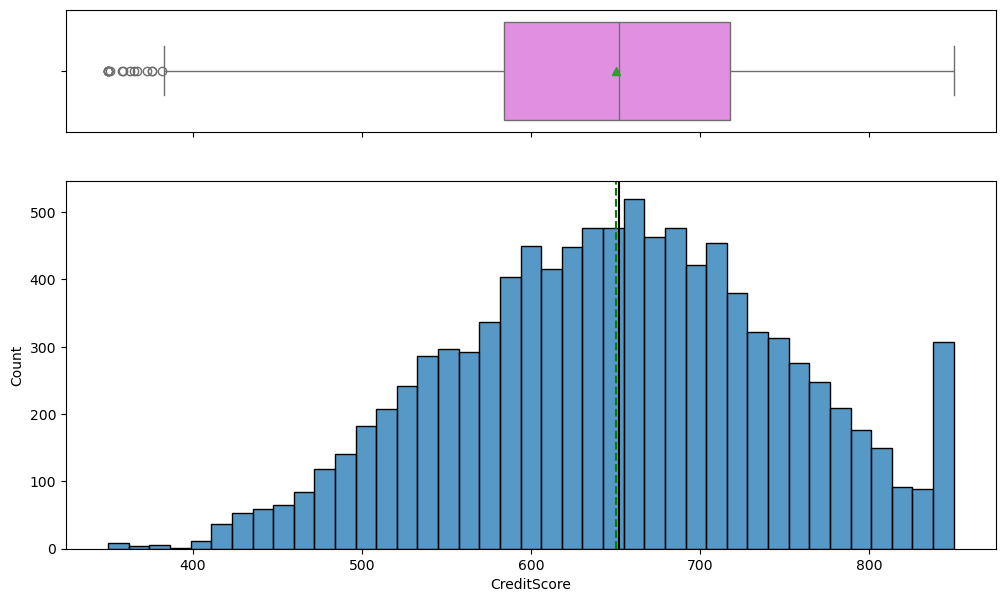

In [35]:
histogram_boxplot(df, 'CreditScore')

**Insights:**

1. Distribution Shape (Histogram):

- Approximately Normal: The histogram shows a roughly bell-shaped distribution, suggesting that CreditScore is approximately normally distributed. This is a common and often desirable characteristic for many statistical models.
- Slight Negative Skew: There's a hint of negative skewness, as the tail on the left side seems slightly longer. However, it's not severe.
- Concentration Around the Mean: The data is concentrated around the center, with fewer data points towards the extreme low and high scores.


2. Central Tendency and Spread (Box Plot):

- Median: The green triangle inside the box represents the median (middle value). It appears to be around 650-670, which aligns with the center of the histogram.
- Interquartile Range (IQR): The box itself spans the interquartile range (IQR), containing the middle 50% of the data. It looks like it ranges from roughly 580 to 720. This gives a good sense of the typical range of credit scores.
- Whiskers: The "whiskers" extend to the minimum and maximum values within 1.5 times the IQR from the box's edges. They capture the typical range of the data, excluding outliers.
- Outliers: The circles plotted beyond the whiskers on the left side indicate outliers. These are credit scores significantly lower than the typical range. They warrant further investigation:
    - Genuine Low Scores? Are these legitimate low credit scores? If so, they represent real customers and should be included in the analysis.
    - Data Errors? Are these due to errors in data entry or measurement? If so, they should be corrected or removed.

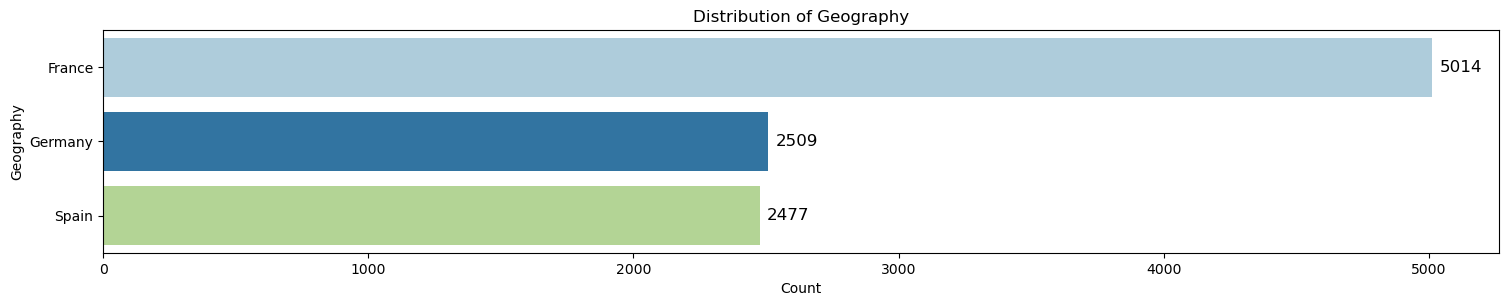

In [37]:
labeled_barplot(df, 'Geography')

**Insights:**

1. Uneven Distribution:
- France Dominates: The most striking observation is that the majority of customers are located in France. The bar for France is significantly taller than the bars for Germany and Spain.
- Germany and Spain Similar: The number of customers in Germany and Spain is relatively close, though Germany has a slightly higher count.


2. Specific Numbers:
- France: Approximately 5014 customers.
- Germany: Approximately 2509 customers.
- Spain: Approximately 2477 customers.

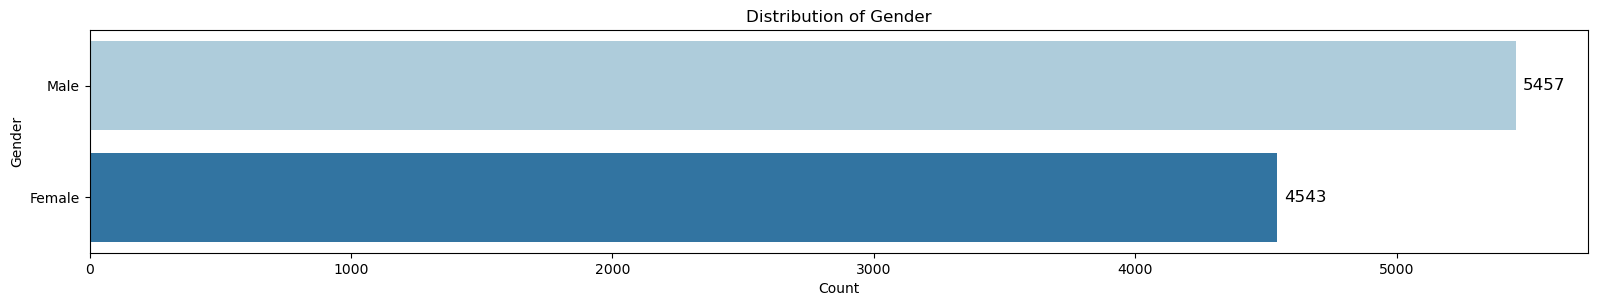

In [39]:
labeled_barplot(df, 'Gender')

**Insights:**

1. Near-Equal Representation:
- Balanced Gender Ratio: The most important observation is that there's a relatively balanced representation of both genders. The bars for Male and Female are of similar length.
- Slight Male Dominance: There are slightly more male customers than female customers, but the difference is not substantial.


2. Specific Numbers:
- Male: Approximately 5457 customers.
- Female: Approximately 4543 customers.

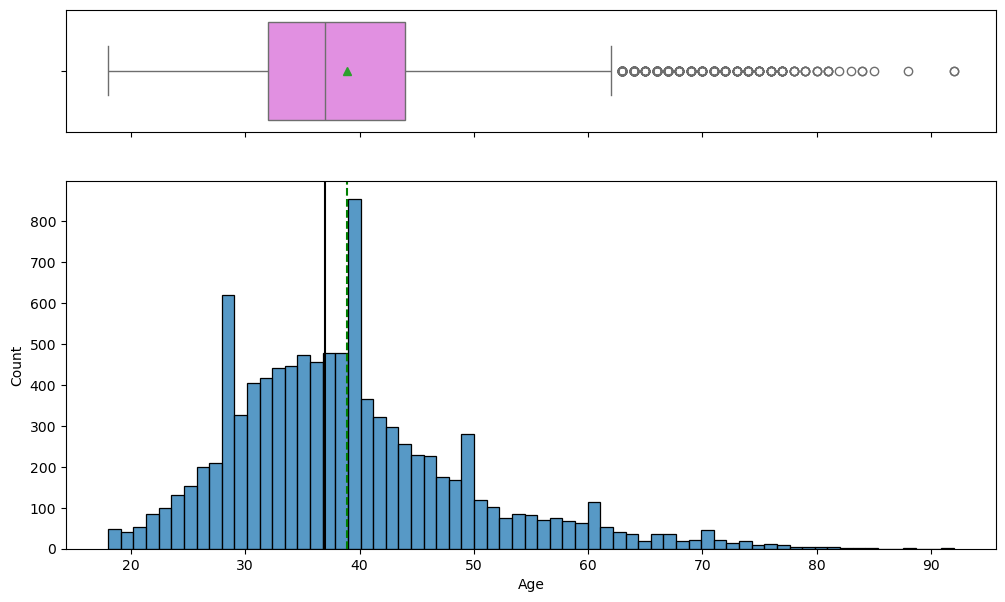

In [41]:
histogram_boxplot(df, 'Age')

**Insights:**

1. Distribution Shape (Histogram):
- Not Normal: The histogram clearly shows that the age distribution is not normally distributed. It's positively skewed (right-tailed), meaning there's a concentration of younger customers and a long tail extending towards older ages.
- Peaks and Bins: There are distinct peaks in the histogram, particularly around the late 30s and early 40s. The data is grouped into discrete age bins (likely integers), which is typical for age data.
- Frequency Decline with Age: The frequency of customers generally declines as age increases, as shown by the right tail.


2. Central Tendency and Spread (Box Plot):
- Median: The green triangle inside the box indicates the median age, which appears to be in the late 30s or around 40. This is consistent with the histogram's peaks.
- Interquartile Range (IQR): The box spans the IQR, representing the middle 50% of ages. It seems to range from roughly 30 to 50.
- Whiskers: The whiskers extend to the minimum and maximum ages within 1.5 times the IQR from the box.
- Outliers: The circles beyond the right whisker indicate outliers – customers with significantly higher ages than the typical range.

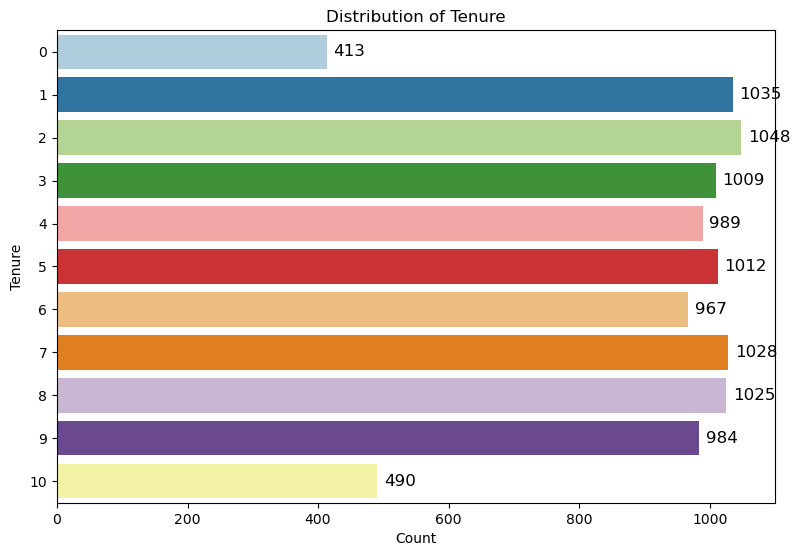

In [43]:
labeled_barplot(df, 'Tenure')

**Insights:**

1. General Distribution:
- Relatively Even Spread: The bars are all roughly the same length, indicating a relatively even distribution of customers across different tenure levels. There's no single tenure that overwhelmingly dominates.
- Slight Variations: While generally even, there are some minor variations. Tenures 1 through 9 have slightly higher counts than tenure 0 or 10.


2. Specific Observations:
- Tenure 0 and 10: These tenures have the lowest number of customers. Tenure 0 might represent newer customers, and tenure 10 might represent customers who have stayed for a very long time.
- Tenures 1-9: These tenures have a fairly consistent number of customers, suggesting a stable distribution across these durations.

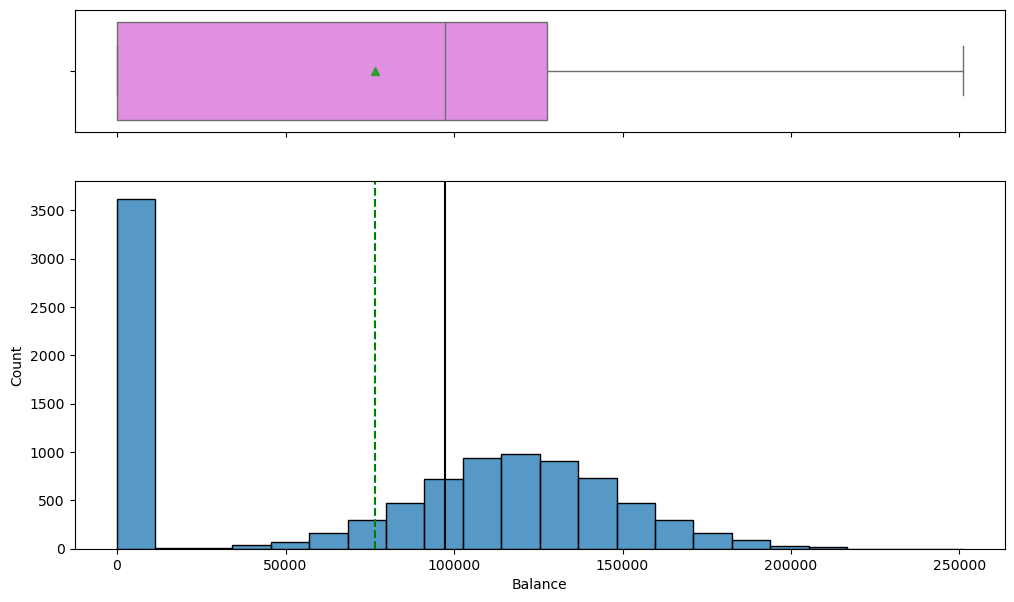

In [45]:
histogram_boxplot(df, 'Balance')

**Insights:**

1. Distribution Shape (Histogram):
- Bimodal or Two Groups: The histogram strongly suggests a bimodal distribution or, more accurately, two distinct groups of customers:
- Zero Balance Group: A large spike at the far left indicates a substantial number of customers with a zero balance.
- Varying Balance Group: The rest of the data, excluding the zero balances, forms a distribution that is skewed to the right. This group represents customers with non-zero balances, and their balances vary considerably.
- Right Skew (Non-Zero Balances): The non-zero balances are positively skewed, meaning there are more customers with lower balances in this group, and a long tail extending towards very high balances.


2. Central Tendency and Spread (Box Plot):
- Median: The green triangle in the box plot represents the median. Given the large number of zero balances, the median is likely to be close to or at zero.
- Interquartile Range (IQR): The box, representing the IQR (middle 50% of the data), is likely compressed towards the lower end of the non-zero balances due to the right skew.
- Whiskers: The whiskers probably don't extend very far due to the skewness and the presence of outliers.
- Outliers: The circles on the right side of the box plot clearly indicate outliers – customers with exceptionally high balances.

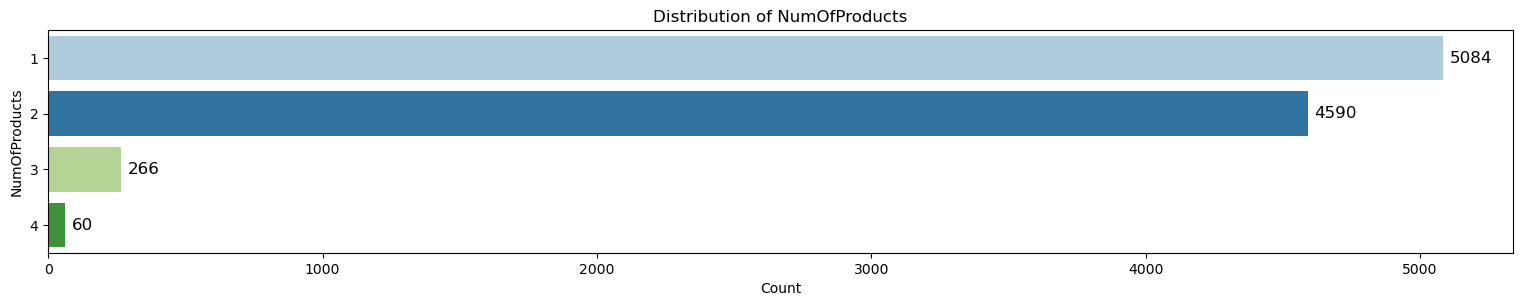

In [47]:
labeled_barplot(df, 'NumOfProducts')

**Insights:**

1. Uneven Distribution Across Product Counts:
- Majority Have 1 or 2 Products: The vast majority of customers have either 1 or 2 products. The bars for these categories are significantly longer than those for 3 or 4 products.
- Few Customers with 3 or 4 Products: The number of customers with 3 or 4 products is substantially lower, suggesting that these customers are less common.

2. Specific Numbers:
- 1 Product: Approximately 5084 customers.
- 2 Products: Approximately 4590 customers.
- 3 Products: Approximately 266 customers.
- 4 Products: Approximately 60 customers.

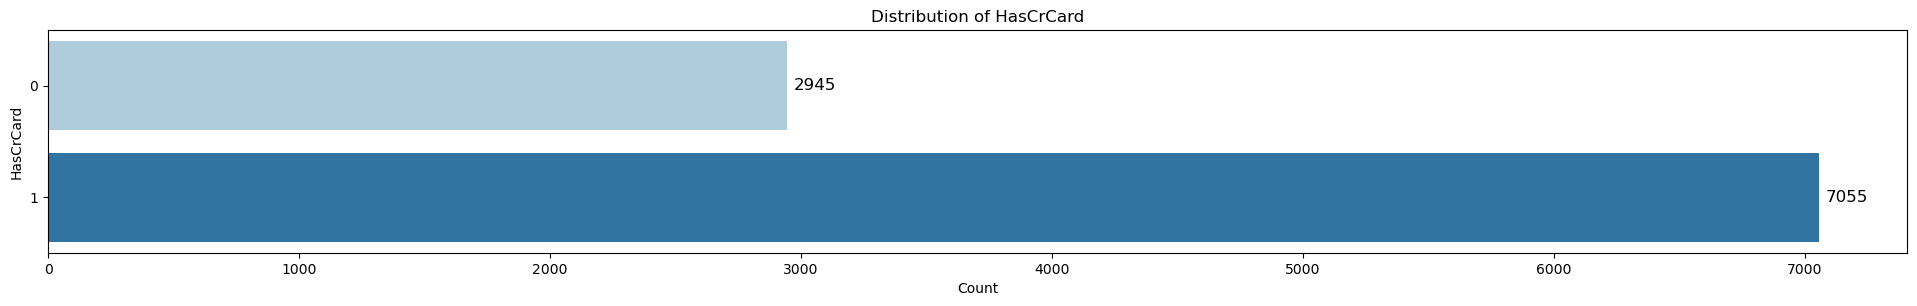

In [49]:
labeled_barplot(df, 'HasCrCard')

**Insights:**

1. Binary Feature:
- Two Categories: The plot clearly shows two distinct groups: customers who have a credit card (represented by 1) and those who don't (represented by 0).
2. Uneven Distribution:
- Majority Have Credit Cards: The bar for "1" (has credit card) is much longer than the bar for "0" (does not have credit card), indicating that the majority of customers in the dataset have a credit card.
3. Specific Numbers:
- Has Credit Card (1): Approximately 7055 customers.
- Does Not Have Credit Card (0): Approximately 2945 customers.

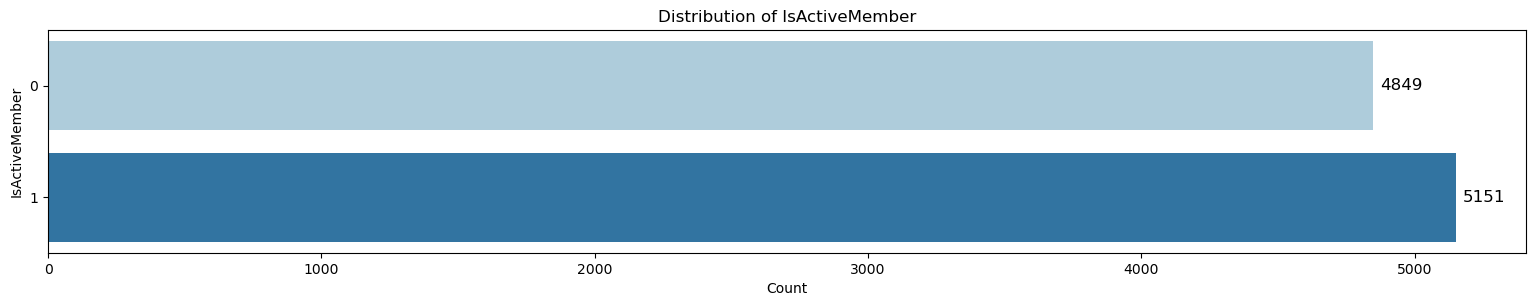

In [51]:
labeled_barplot(df, 'IsActiveMember')

**Insights:**

1. Binary Feature:
- Two Categories: The plot clearly shows two distinct groups: customers who are active members (represented by 1) and those who are not (represented by 0).
2. Near-Equal Distribution:
- Relatively Balanced: The bars for both "1" (active member) and "0" (not active member) are roughly the same length, indicating a near-equal split between the two groups.
- Slightly More Active Members: There are slightly more active members than inactive members, but the difference is not substantial.
3. Specific Numbers:
- Active Member (1): Approximately 5151 customers.
- Not Active Member (0): Approximately 4849 customers.

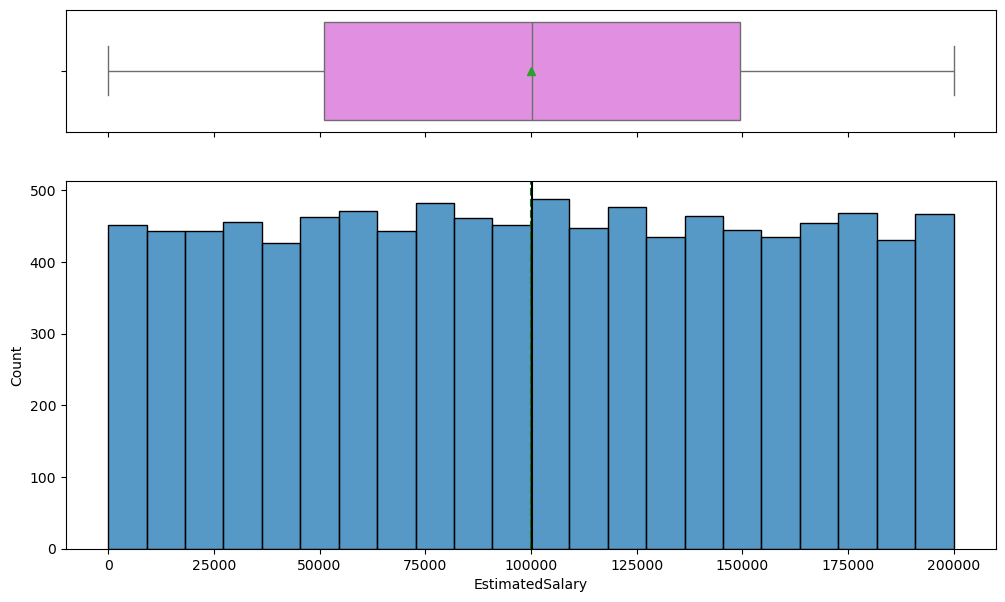

In [53]:
histogram_boxplot(df, 'EstimatedSalary')

**Insights:**

1. Distribution Shape (Histogram):
- Uniform-ish Distribution: The histogram shows a roughly uniform distribution across the range of salaries. While not perfectly flat, the bars don't show any strong peaks or concentrations in specific salary ranges.
- No Obvious Skew: There's no clear evidence of significant skewness in either direction.
2. Central Tendency and Spread (Box Plot):
- Median: The green triangle in the box plot represents the median salary. It appears to be around the middle of the salary range, which is consistent with the uniform distribution observed in the histogram.
- Interquartile Range (IQR): The box, representing the IQR (middle 50% of the data), spans a substantial portion of the salary range, again reflecting the uniform distribution.
- Whiskers: The whiskers extend to the minimum and maximum values, indicating that there are no significant outliers in terms of extremely high or low salaries.

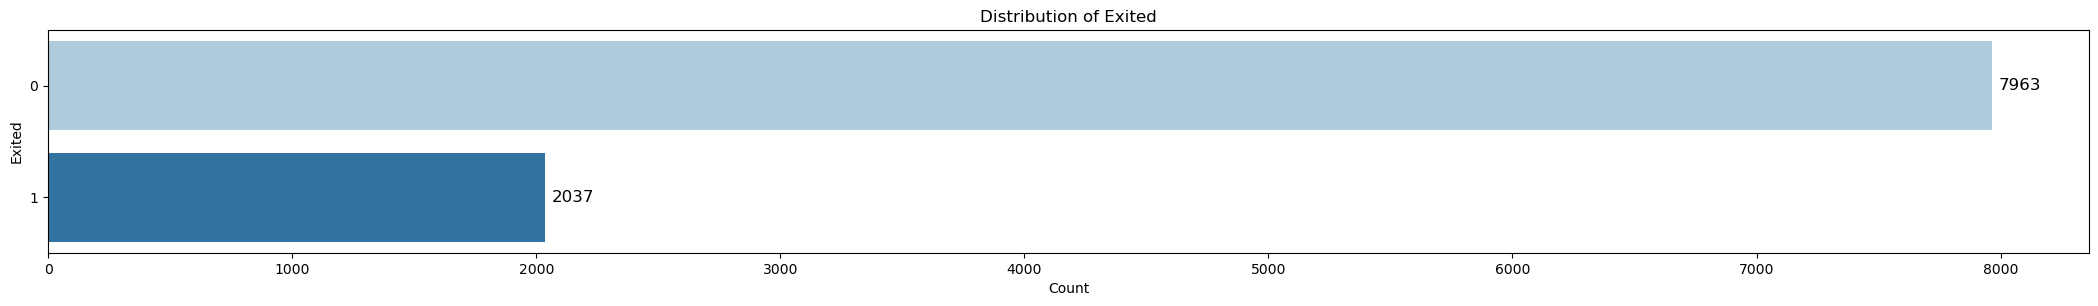

In [55]:
labeled_barplot(df, 'Exited')

**Insights:**

1. Binary Classification Problem:
- Two Categories: The plot clearly represents a binary classification problem with two classes: "0" (customer stayed) and "1" (customer exited/churned).
2. Class Imbalance:
- Uneven Distribution: The bars show a clear imbalance between the two classes. The "0" (stayed) bar is much longer than the "1" (exited) bar, indicating that the majority of customers have stayed with the bank.
3. Specific Numbers:
- Stayed (0): Approximately 7963 customers.
- Exited (1): Approximately 2037 customers.

### Bivariate Analysis

<Axes: >

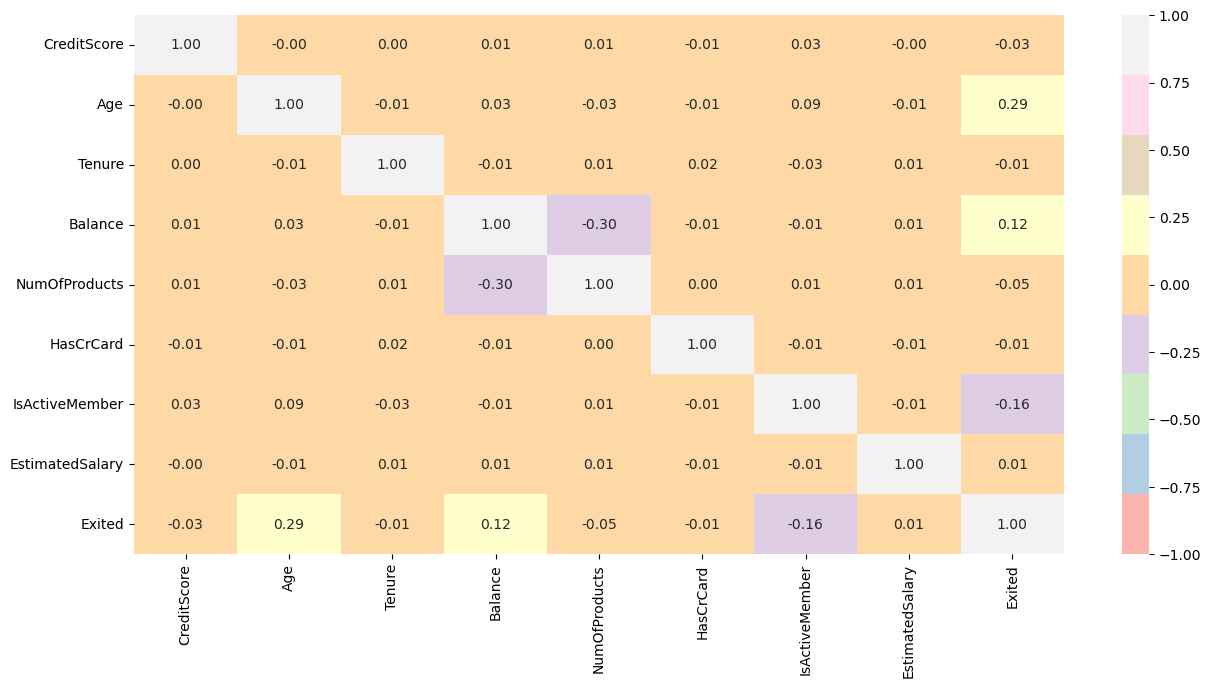

In [58]:
plt.figure(figsize=(15,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Pastel1', fmt='.2f', vmin=-1, vmax=1)

**Key Observations:**

*Age and Exited:*
- Positive Correlation (0.29): There's a noticeable positive correlation between Age and Exited (whether a customer churned). This suggests that older customers are more likely to churn.


*Balance and Exited:*
- Positive Correlation (0.12): There's a weak positive correlation between Balance and Exited. Customers with higher balances are slightly more likely to churn.


*IsActiveMember and Exited:*
- Negative Correlation (-0.16): There's a moderate negative correlation between IsActiveMember and Exited. Inactive members are more likely to churn, which is intuitive.


*NumOfProducts and Balance:*
- Negative Correlation (-0.30): There's a moderate negative correlation between NumOfProducts and Balance. Customers with more products tend to have lower balances. This might be because they are spreading their funds across multiple accounts or product types, or it could indicate different customer segments.


*Age and Balance:*
- Weak Positive Correlation (0.03): There's a weak positive correlation between Age and Balance. Older customers tend to have slightly higher balances, although the relationship is not very strong.


*Tenure and Age:*
- Weak Negative Correlation (-0.01): There's a very weak negative correlation between Tenure and Age.


*Near-Zero Correlations:*
- Most other pairs of variables have near-zero correlations, suggesting little to no linear relationship between them.


**Implications and Next Steps:**
- Feature Importance: The correlations suggest that Age, IsActiveMember, Balance, and NumOfProducts are likely to be important features for predicting churn (Exited).
- Model Selection: Better using models that can handle these relationships effectively. Tree-based models (like Random Forests or Gradient Boosting) can capture non-linear relationships and interactions between these variables.
- Feature Engineering: I might consider creating interaction features (e.g., combining Age and Balance or IsActiveMember and NumOfProducts) to capture more complex relationships.
- Multicollinearity: There are no strongly correlated pairs of independent variables (other than the relationships with Exited), so multicollinearity is likely not a major concern.
- Further Analysis: Explore the reasons behind the observed correlations. For example, why are older customers more likely to churn? What drives the negative correlation between NumOfProducts and Balance? Understanding these relationships can provide valuable business insights.


**In summary:**
The heatmap reveals some interesting relationships, particularly between Age, IsActiveMember, Balance, NumOfProducts, and Exited. These insights can inform feature selection, model selection, and further analysis to understand the drivers of customer churn. 

In [60]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

def calculate_cramers_v(x, y):
    """
    Calculate Cramér’s V for two categorical pandas Series x and y.
    
    Parameters:
    - x: pandas Series, first categorical variable
    - y: pandas Series, second categorical variable

    Returns:
    - Cramér’s V value, a measure of association between the two variables.
    """
    # Create a contingency table for the two variables
    confusion_matrix = pd.crosstab(x, y)

    # Perform the chi-squared test on the contingency table
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)

    # Total number of observations
    n = confusion_matrix.sum().sum()

    # Number of rows and columns
    r, k = confusion_matrix.shape

    # Compute and return Cramér’s V
    return np.sqrt((chi2 / n) / (min(k - 1, r - 1)))


def get_sorted_cramers_v_scores(dataframe, target_column, 
                                bin_numeric=True, numeric_bins=10, 
                                exclude_columns=None):
    """
    Calculate and return sorted Cramér’s V scores for all features against a target column.
    
    This version includes:
      - Optional discretization (binning) of numeric features with many unique values.
      - The ability to exclude specific columns (e.g., unique identifiers).

    Parameters:
    - dataframe: pandas DataFrame containing features and target variable.
    - target_column: str, name of the target column to compare other features against.
    - bin_numeric: bool (default True). If True, numeric features with many unique values will be binned.
    - numeric_bins: int (default 10). The number of bins to use when binning numeric features.
    - exclude_columns: list or set (default None). Columns to be excluded from the analysis.
    
    Returns:
    - A sorted pandas DataFrame with columns 'Feature' and 'Cramér’s V Score', in descending order.
    """
    scores = {}
    
    # Ensure exclude_columns is a set for faster lookup if provided
    if exclude_columns is None:
        exclude_columns = set()
    else:
        exclude_columns = set(exclude_columns)
    
    for column in dataframe.columns:
        if column == target_column or column in exclude_columns:
            continue

        series = dataframe[column]
        
        # Skip potential identifier columns: if each value is unique, ignore this column.
        if series.nunique() == len(series):
            continue

        # For numeric columns, optionally bin the data if there are many unique values.
        if pd.api.types.is_numeric_dtype(series):
            if bin_numeric and series.nunique() > numeric_bins:
                # Use pd.cut to discretize into bins.
                # The 'duplicates' parameter ensures that if bin edges are not unique,
                # the binning will still work.
                series = pd.cut(series, bins=numeric_bins, duplicates='drop')
        
        # Calculate Cramér’s V for this (possibly discretized) feature versus the target.
        try:
            scores[column] = calculate_cramers_v(series, dataframe[target_column])
        except Exception as e:
            print(f"Error calculating Cramér’s V for column {column}: {e}")
            scores[column] = np.nan
    
    # Create a DataFrame from the scores dictionary and sort it in descending order.
    scores_df = pd.DataFrame(scores.items(), columns=['Feature', 'Cramér’s V Score'])
    sorted_scores_df = scores_df.sort_values(by='Cramér’s V Score', ascending=False).reset_index(drop=True)
    
    return sorted_scores_df

sorted_cramers_v_scores = get_sorted_cramers_v_scores(df, 'Exited')

table_styler_and_display(sorted_cramers_v_scores, "Sorted Cramér’s V Scores:")

### Sorted Cramér’s V Scores:

,Feature,Cramér’s V Score
0,NumOfProducts,0.387767
1,Age,0.376197
2,Geography,0.173567
3,IsActiveMember,0.155880
4,Balance,0.143674
5,Gender,0.106263
6,CreditScore,0.091179
7,Tenure,0.037199
8,EstimatedSalary,0.022258
9,HasCrCard,0.006865


**Understanding Cramér's V:**


*Strength of Association:* Cramér's V ranges from 0 to 1:
- 0: No association between the variables.
- 1: Perfect association (knowing the value of one variable perfectly predicts the value of the other).
- Categorical Variables: It's specifically designed for categorical variables. While some of your features are numerical, they are being treated as categorical here (likely binned or grouped).


**Key Observations:**


*Top Predictors:*
- NumOfProducts (0.388): The strongest association with Exited. The number of products a customer has is a good indicator of churn. This aligns with our previous observations.
- Age (0.376): Also a strong association. Age is an important factor in predicting churn. Older customers are more likely to leave.
- Geography (0.174): A moderate association. A customer's location has some influence on churn.
- IsActiveMember (0.156): A moderate association. Inactive members are more likely to churn.


*Moderate Predictors:*
- Balance (0.144): A weak to moderate association. Customers with higher balances are slightly more likely to churn.
- Gender (0.106): A weak association. Gender has some influence on churn.


*Weak Predictors:*
- CreditScore (0.091): A weak association. Credit score has a small influence on churn.
- Tenure (0.037): A very weak association. Tenure (how long a customer has been with the bank) has minimal influence on churn in this analysis.
- EstimatedSalary (0.022): A very weak association. Salary has almost no influence on churn in this analysis.
- HasCrCard (0.007): An extremely weak association. Whether a customer has a credit card or not has virtually no influence on churn.


**Implications and Next Steps:**
- Feature Selection: NumOfProducts, Age, Geography, and IsActiveMember stand out as the most important categorical predictors of churn based on Cramér's V.
- Model Building: Consider these features prominently in the model. Tree-based models or models that handle categorical variables well are likely to be effective.
- Further Analysis: Investigate the relationships in more detail. For example, how does the churn rate vary across different age groups or product combinations? Visualizations (like stacked bar charts or grouped bar charts) can be helpful here.
- Feature Engineering: I can consider creating interaction features (e.g., combining Age and NumOfProducts) to capture more complex relationships.
- Consider Numerical Nature: Remember that Balance, CreditScore, Tenure, and EstimatedSalary are numerical. While they've been treated as categorical here, I might get more information by using them as numerical features in some models (after appropriate scaling). The low Cramér's V scores might be because they were treated as categorical.

    
**In summary:**
Cramér's V analysis highlights NumOfProducts, Age, Geography, and IsActiveMember as the strongest categorical predictors of churn.  The other variables show weaker associations. 

**Combined Insights and Recommendations:**
- Focus on NumOfProducts and Age: These are clearly important predictors and should be central to the modeling strategy.
- Explore Interactions: Investigate interactions between NumOfProducts, Age, Balance, and IsActiveMember. For example, are older customers with fewer products and higher balances more likely to churn?
- Don't Dismiss Numerical Features: While CreditScore, Tenure, EstimatedSalary showed weak associations in this categorical analysis, consider their numerical nature and explore their relationships with churn using appropriate methods (scatter plots, correlation analysis for numerical variables, etc.).
- Feature Engineering: Create interaction features (e.g., Age x NumOfProducts, Balance x IsActiveMember) to capture potential combined effects.
- Model Selection: Choose models that can handle both categorical and numerical features well and can capture interactions. Tree-based models, some ensemble methods, or potentially neural networks are good candidates.


**In essence:**
Combining the insights from the heatmap and Cramér's V gives a more holistic view.  NumOfProducts and Age stand out, but the relationships are complex.  Don't ignore the numerical nature of some features, and explore interactions to build a more effective model.

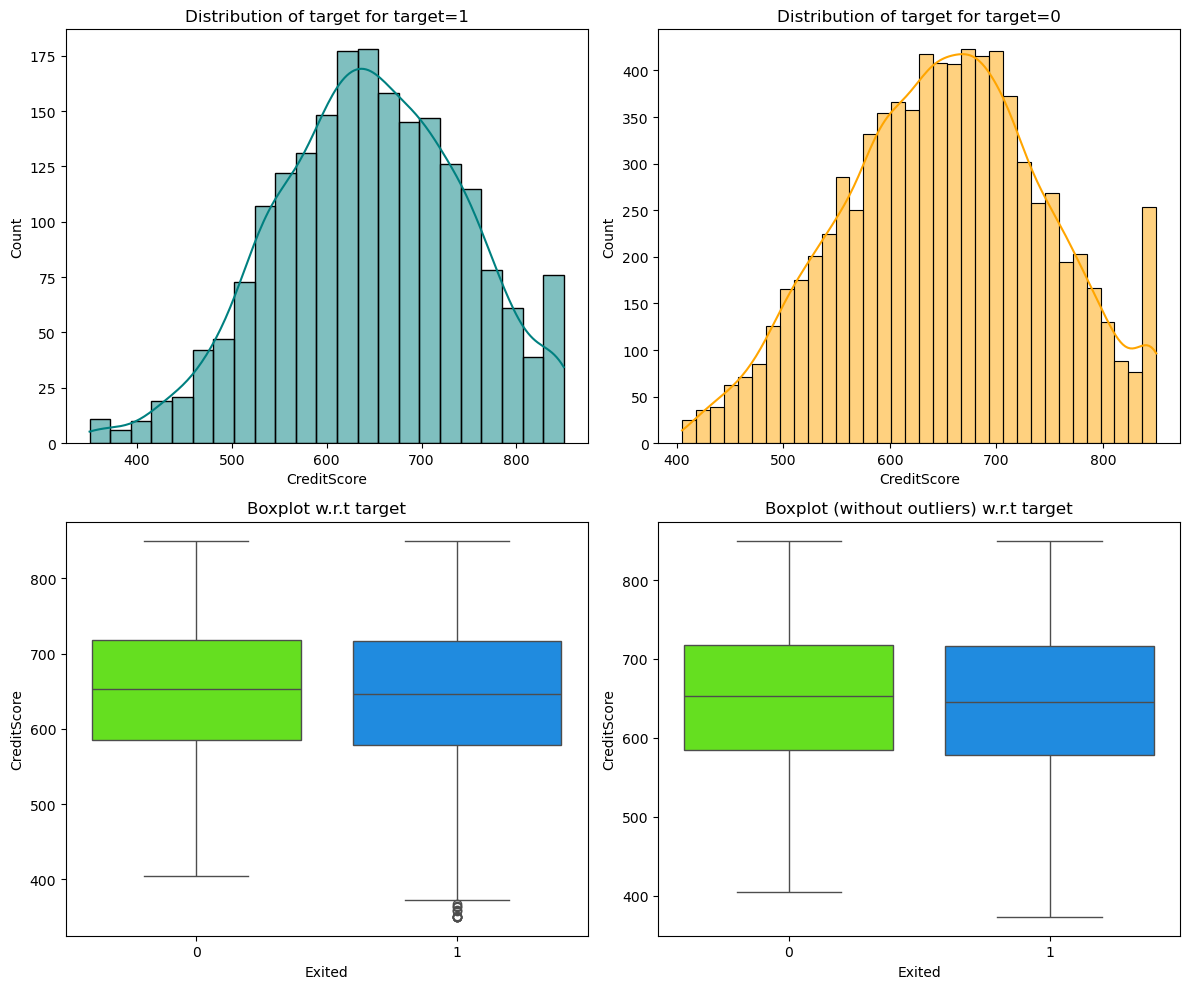

In [63]:
distribution_plot_wrt_target(df, 'CreditScore', 'Exited')

1. Histograms of CreditScore by Exited:
- Separation: The two histograms show the distribution of CreditScore for customers who exited (target=1) and those who stayed (target=0). Visually, there's not a dramatic separation between the two distributions. This suggests that CreditScore alone might not be the strongest predictor of churn, but it likely still holds some information.
- Shape: Both histograms appear somewhat normally distributed, although there might be slight variations in skewness.
- Range: The range of credit scores seems similar for both groups, although there might be subtle differences in the frequencies within certain ranges.
2. Box Plots of CreditScore by Exited:
- Median Difference: The box plots show the median CreditScore for both groups. The median for the "exited" group (1) seems slightly lower than the median for the "stayed" group (0). This suggests that customers who churned tend to have slightly lower credit scores on average.
- IQR Overlap: There's a significant overlap in the interquartile ranges (IQRs) of the two groups. This further reinforces the idea that CreditScore alone might not be a strong separator, as a substantial portion of customers in both groups have similar credit scores.

Exited        0     1    All
Geography                   
All        7963  2037  10000
Germany    1695   814   2509
France     4204   810   5014
Spain      2064   413   2477
------------------------------------------------------------------------------------------------------------------------


<Figure size 1500x300 with 0 Axes>

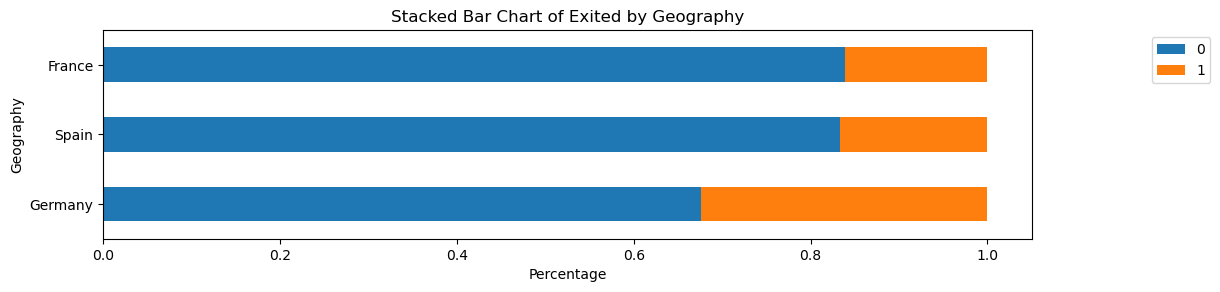

In [65]:
stacked_barplot(df, 'Geography', 'Exited')

**Insights:**

*Visual Representation of Proportions:* The stacked bar chart visually represents the proportion of churned and stayed customers within each country.
- Germany's Higher Churn: The chart clearly shows that Germany has a noticeably higher proportion of churned customers compared to France and Spain.
- France and Spain Similar: The proportions of churned customers in France and Spain appear to be similar.

Exited     0     1    All
Gender                   
All     7963  2037  10000
Female  3404  1139   4543
Male    4559   898   5457
------------------------------------------------------------------------------------------------------------------------


<Figure size 1400x300 with 0 Axes>

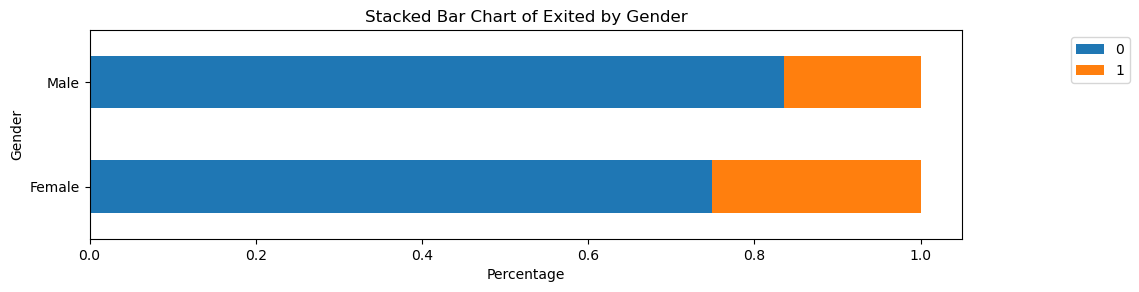

In [67]:
stacked_barplot(df, 'Gender', 'Exited')

**Insights:**

- Similar Proportions: The bars for Male and Female are roughly the same length, suggesting that the overall churn rate is relatively similar between the two genders.
- Slightly Higher Female Churn: Visually, the orange portion (representing churn, Exited=1) seems slightly larger for females than for males. This suggests that females might have a slightly higher churn rate, but the difference is not dramatic.

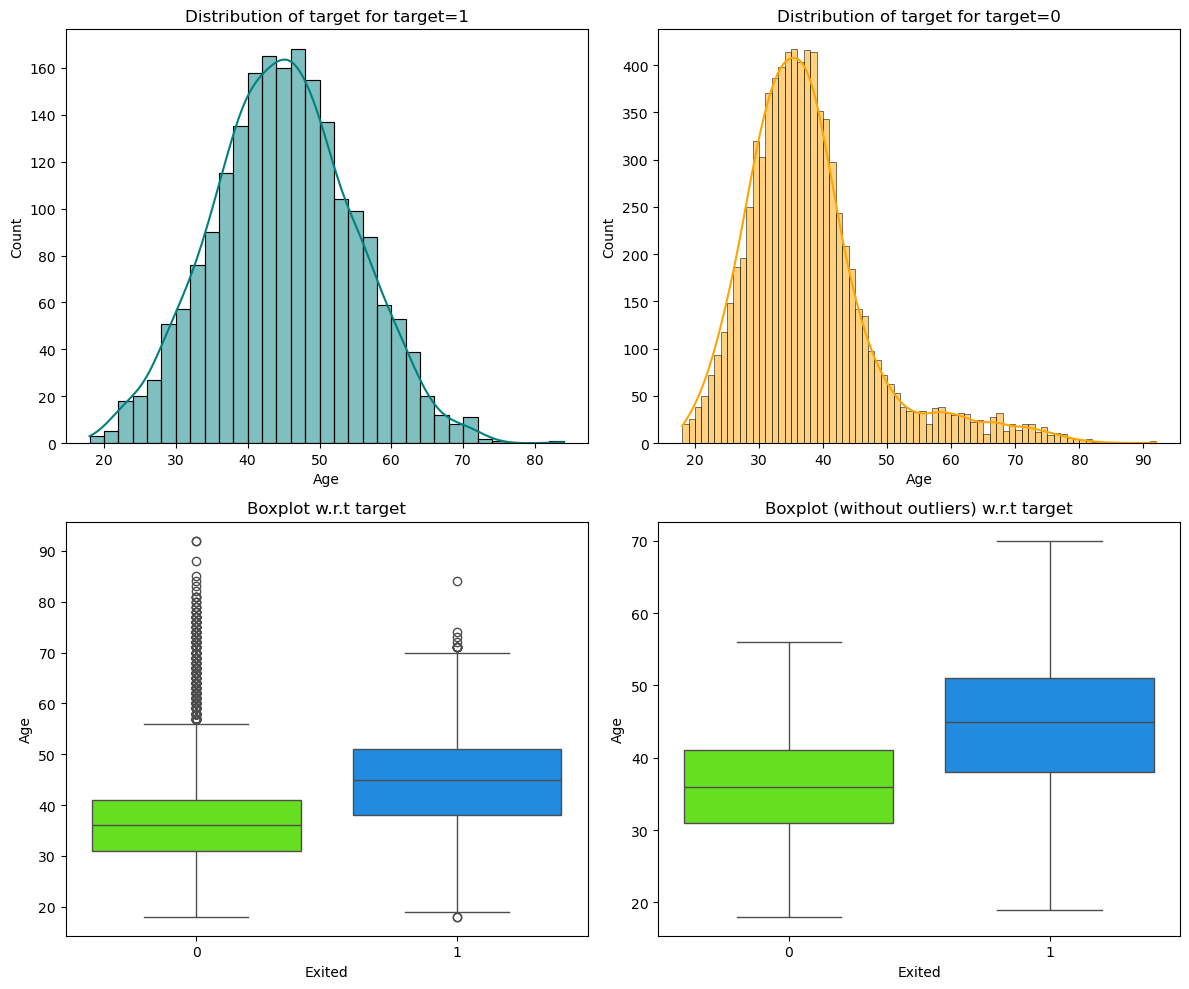

In [69]:
distribution_plot_wrt_target(df, 'Age', 'Exited')

1. Histograms of Age by Exited:
- Shift in Distributions: The two histograms show the distribution of Age for customers who exited (target=1) and those who stayed (target=0). There's a noticeable shift in the distributions. The "exited" group tends to be older than the "stayed" group.
- Shape: Both histograms appear somewhat normally distributed, although there might be slight variations in skewness. The distribution for "exited" customers seems to have a wider spread.
- Range: The range of ages seems wider for the "exited" group, with a higher upper bound.
2. Box Plots of Age by Exited:

- Median Difference: The box plots clearly show a difference in the median ages between the two groups. The median age for the "exited" group is noticeably higher than the median age for the "stayed" group.
- IQR Shift: The interquartile ranges (IQRs) also show a shift towards older ages for the "exited" group.

Exited     0     1    All
Tenure                   
All     7963  2037  10000
1        803   232   1035
3        796   213   1009
9        771   213    984
5        803   209   1012
4        786   203    989
2        847   201   1048
8        828   197   1025
6        771   196    967
7        851   177   1028
10       389   101    490
0        318    95    413
------------------------------------------------------------------------------------------------------------------------


<Figure size 1500x550 with 0 Axes>

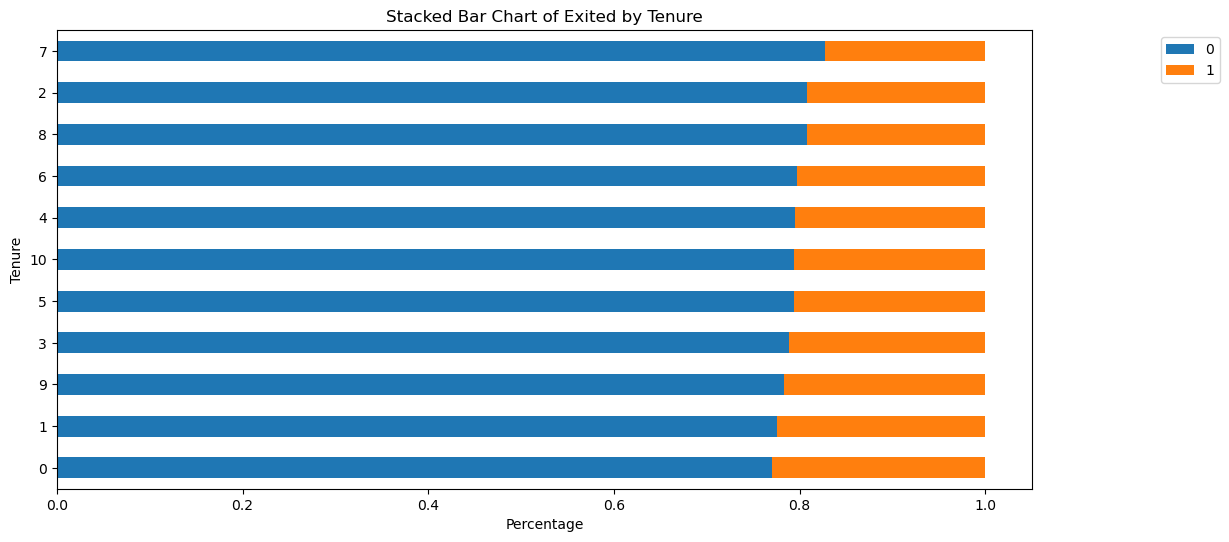

In [71]:
stacked_barplot(df, 'Tenure', 'Exited')

**Insights:**

- Varying Churn Across Tenure: The proportion of churn (orange portion) varies across different tenures.
- Higher Churn at Certain Tenures: Visually, it appears that churn might be slightly higher at tenures 0, 1, and perhaps around 4-6, while it seems lower at tenures 2, 8, and 9.

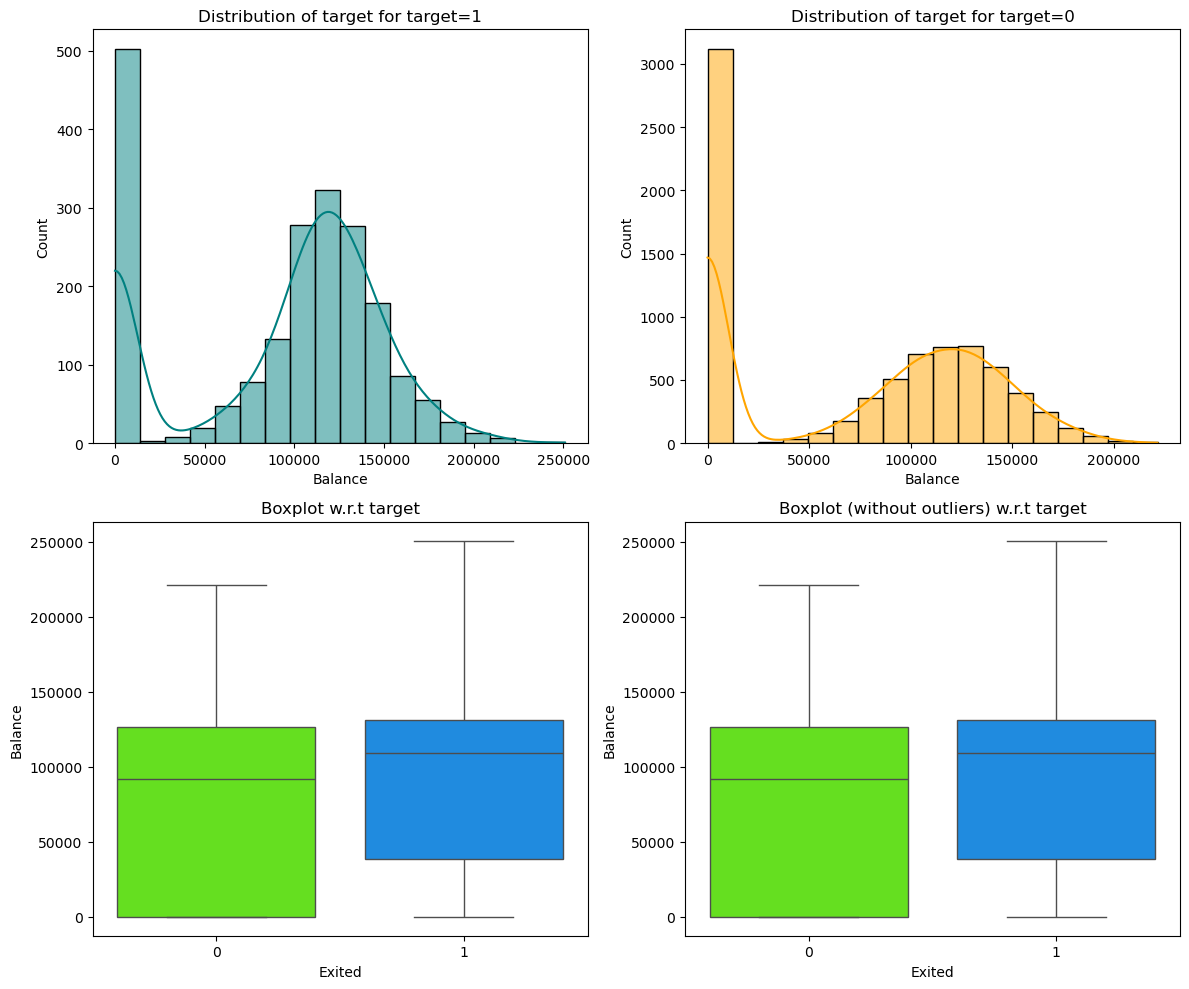

In [73]:
distribution_plot_wrt_target(df, 'Balance', 'Exited')

1. Histograms of Balance by Exited:

- Distinct Distributions: The two histograms show the distribution of Balance for customers who exited (target=1) and those who stayed (target=0). There are clear differences in the distributions.
- Zero Balance Spike: The histogram for "stayed" customers (target=0) has a very large spike at 0 balance, indicating a substantial number of customers with no balance. This spike is much less prominent in the "exited" group.
- Shift in Non-Zero Balances: For non-zero balances, the distribution for "exited" customers seems to be shifted slightly towards higher balances compared to the "stayed" group.
- Shape: The non-zero balances in both histograms appear positively skewed (right-tailed).
2. Box Plots of Balance by Exited:

- Median Difference: The box plots show a clear difference in the median balances between the two groups. The median balance for the "exited" group is noticeably higher than the median balance for the "stayed" group.
- IQR Shift: The interquartile ranges (IQRs) also show a shift towards higher balances for the "exited" group.

Exited            0     1    All
NumOfProducts                   
All            7963  2037  10000
1              3675  1409   5084
2              4242   348   4590
3                46   220    266
4                 0    60     60
------------------------------------------------------------------------------------------------------------------------


<Figure size 1500x300 with 0 Axes>

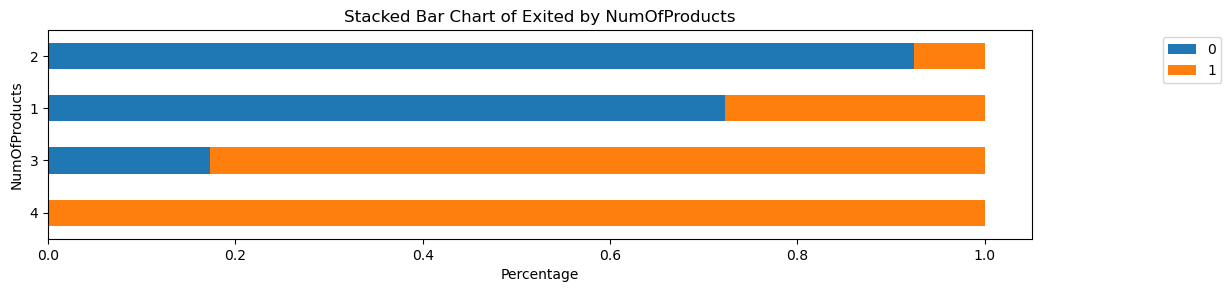

In [75]:
stacked_barplot(df, 'NumOfProducts', 'Exited')

**Insights:**

- Clear Trend: The chart reveals a strange trend: customers with more products are significantly more likely to churn.
- Increasing Churn with More Products: The proportion of churn (orange portion) Increase noticeably as the number of products increases. Customers with 4 products have the higher churn rate, while those with 2 product have the lowest.

Exited        0     1    All
HasCrCard                   
All        7963  2037  10000
1          5631  1424   7055
0          2332   613   2945
------------------------------------------------------------------------------------------------------------------------


<Figure size 1400x300 with 0 Axes>

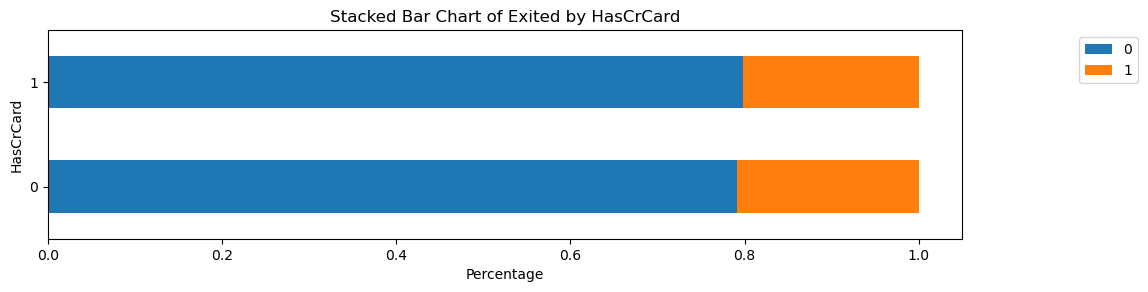

In [77]:
stacked_barplot(df, 'HasCrCard', 'Exited')

**Insights:**

- Similar Proportions: The bars for customers with a credit card (1) and those without (0) are roughly the same length, suggesting that the overall churn rate is relatively similar between the two groups.
- Slightly Higher Churn for Non-Card Holders: Visually, the orange portion (representing churn, Exited=1) seems slightly larger for customers without a credit card (0) than for those with one (1). This suggests that customers without a credit card might have a slightly higher churn rate, but the difference is not dramatic.

Exited             0     1    All
IsActiveMember                   
All             7963  2037  10000
0               3547  1302   4849
1               4416   735   5151
------------------------------------------------------------------------------------------------------------------------


<Figure size 1400x300 with 0 Axes>

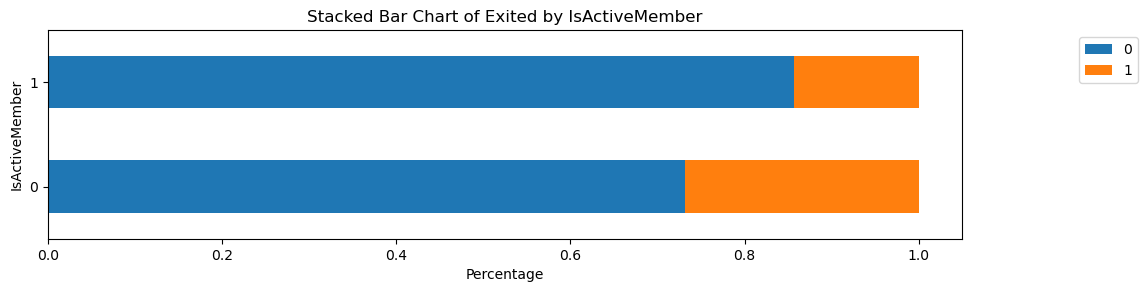

In [79]:
stacked_barplot(df, 'IsActiveMember', 'Exited')

**Insight:**

- Clear Difference: The chart clearly shows a difference in churn rates between active and inactive members. The proportion of churned customers (orange portion) is noticeably higher for inactive members (0) than for active members (1).
- Higher Churn for Inactive Members: This suggests that inactive members are significantly more likely to churn than active members.

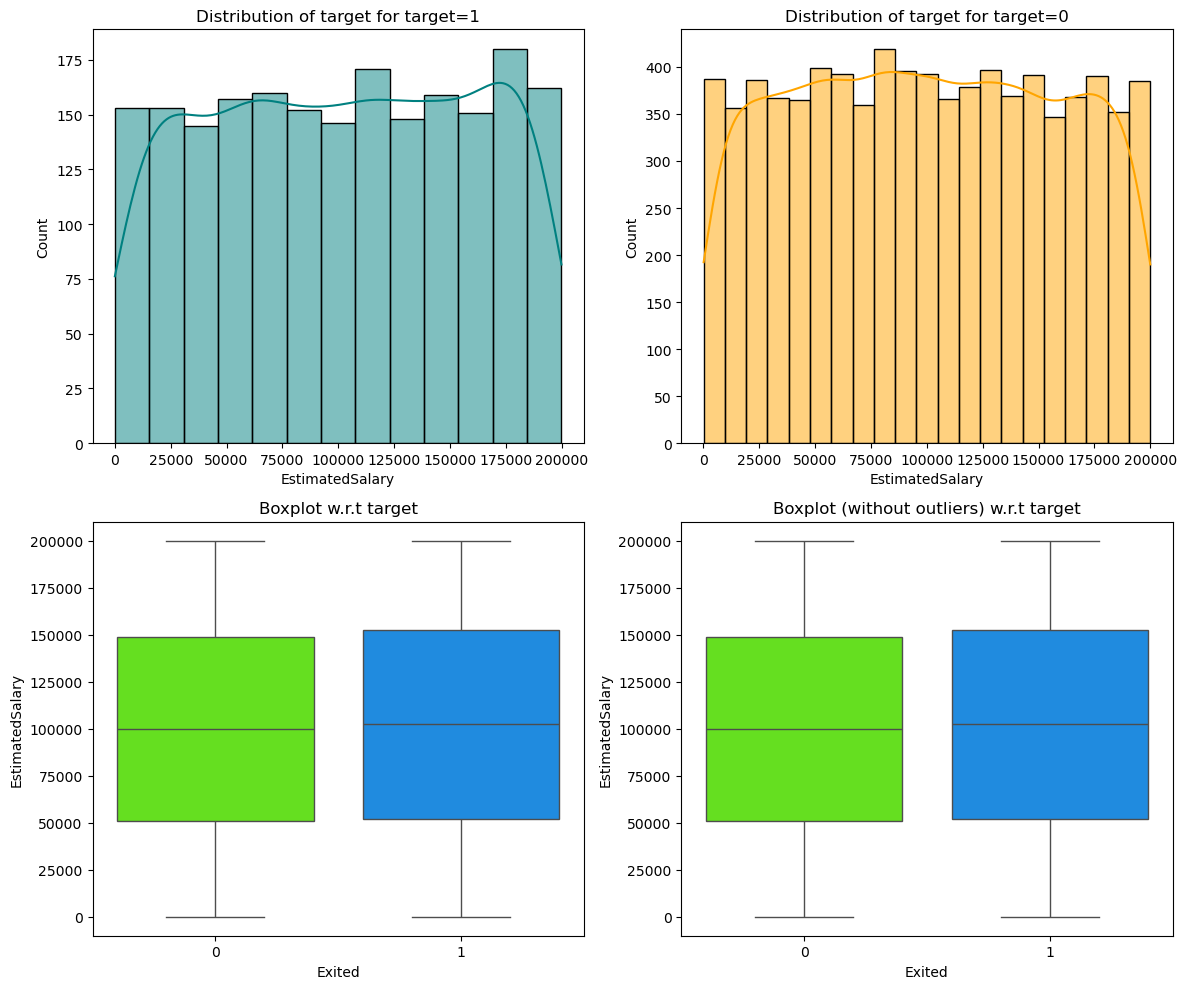

In [81]:
distribution_plot_wrt_target(df, 'EstimatedSalary', 'Exited')

1. Histograms of EstimatedSalary by Exited:

- Overlapping Distributions: The two histograms show the distribution of EstimatedSalary for customers who exited (target=1) and those who stayed (target=0). There's a significant overlap between the two distributions, suggesting that EstimatedSalary alone might not be a strong predictor of churn.
- Similar Shape: Both histograms appear somewhat uniformly distributed, although there might be slight variations in the height of bars across different salary ranges.
- Range: The range of estimated salaries seems similar for both groups.
2. Box Plots of EstimatedSalary by Exited:

- Similar Medians: The box plots show that the median estimated salaries for both groups are very similar. The green triangle representing the median is almost at the same level for both "stayed" (0) and "exited" (1) customers.
- Overlapping IQRs: There's a substantial overlap in the interquartile ranges (IQRs) of the two groups. This further reinforces the idea that EstimatedSalary alone might not be a strong separator, as a significant portion of customers in both groups have similar salaries.

## Data Preprocessing

### Dummy Variable Creation

In [85]:
# Separate the features (independent variables) from the target (dependent variable)
# 'X' contains all columns except 'Exited' (features)
X = df.drop(['Exited'], axis=1)

# 'y' contains the target variable (whether a customer exited or not)
y = df['Exited']

In [86]:
# One-hot encode the 'Geography' and 'Gender' categorical columns in the feature set
# drop_first=True avoids multicollinearity by dropping the first category
X_encoded = pd.get_dummies(X, columns=['Geography', 'Gender'], drop_first=True)

In [87]:
X_encoded['Geography_Germany'] = X_encoded['Geography_Germany'].astype(int) # Convert 'Geography_Germany' column to integer type (0 or 1)
X_encoded['Geography_Spain'] = X_encoded['Geography_Spain'].astype(int) # Convert 'Geography_Spain' column to integer type (0 or 1)
X_encoded['Gender_Male'] = X_encoded['Gender_Male'].astype(int) # Convert 'Gender_Male' column to integer type (0 or 1)

# Note: This step is performed because SMOTE (Synthetic Minority Over-sampling Technique) can sometimes change the data type of binary/boolean features to float.
# SMOTE algorithm works by creating synthetic samples between existing minority class samples.
# In some implementations or edge cases, this interpolation process might lead to floating-point values even for binary features.
# To ensure these features remain as integers (0 and 1) for model compatibility and interpretability, we explicitly cast them back to integer type.
# This ensures that the one-hot encoded categorical features are treated as discrete binary values rather than continuous numerical values.

### Train-validation-test Split

In [89]:
# Split the dataset into training and testing sets (80% train, 20% test)
# 'stratify=y' ensures that the class distribution remains consistent across splits
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Further split the training set into training and validation sets (60% train, 20% validation, 20% test overall)
# 'stratify=y_train' ensures class distribution remains balanced in the validation set as well
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, 
    test_size=0.25,  # 0.25 * 0.8 = 0.2 of the original dataset
    random_state=42, 
    stratify=y_train
)

# Reset indices
X_train = X_train.reset_index(drop=True)  # drop=True discards the old indices
y_train = y_train.reset_index(drop=True)

#Now do the same for the y_val and X_val as well
X_val = X_val.reset_index(drop=True)  # drop=True discards the old indices
y_val = y_val.reset_index(drop=True)

#And the same for the y_test and X_test as well
X_test = X_test.reset_index(drop=True)  # drop=True discards the old indices
y_test = y_test.reset_index(drop=True)

In [90]:
# Create a list of dictionaries to store the shapes of each dataset split
dataset_shapes = [
    {
        "Dataset": 'Original',             # Original full dataset
        'Features (X) Shape': X.shape,     # Shape of the feature matrix X
        'Target (y) Shape': y.shape        # Shape of the target variable y
    },
    {
        "Dataset": 'Training',             # Training dataset
        'Features (X) Shape': X_train.shape,  # Shape of training features
        'Target (y) Shape': y_train.shape     # Shape of training target
    },
    {
        "Dataset": 'Validation',           # Validation dataset
        'Features (X) Shape': X_val.shape,   # Shape of validation features
        'Target (y) Shape': y_val.shape      # Shape of validation target
    },
    {
        "Dataset": 'Test',                 # Test dataset
        'Features (X) Shape': X_test.shape,  # Shape of test features
        'Target (y) Shape': y_test.shape     # Shape of test target
    }
]

# Convert the list of dataset shapes into a DataFrame
dataset_shapes_df = pd.DataFrame(dataset_shapes)

# Display the dataset shapes using a custom table styling function
table_styler_and_display(dataset_shapes_df, "Dataset Shape Summary")

### Dataset Shape Summary

,Dataset,Features (X) Shape,Target (y) Shape
0,Original,"(10000, 10)","(10000,)"
1,Training,"(6000, 11)","(6000,)"
2,Validation,"(2000, 11)","(2000,)"
3,Test,"(2000, 11)","(2000,)"


In [91]:
# Define a function to calculate the percentage of a specific class in the target variable
def dependant_class_calc(dep, cls):
    """
    Calculate the percentage of a given class in the target variable.

    Parameters:
        dep (pandas.Series): The target variable.
        cls (int): The class label to calculate the percentage for.

    Returns:
        float: The percentage of the specified class in the target variable.
    """
    return dep[dep == cls].count() / len(dep) * 100

# Create a list of dictionaries containing the class distribution (percentage) for each dataset
class_weights = [
    {
        "Name": 'Original',              # Original dataset
        '0': dependant_class_calc(y, 0),  # Percentage of class '0' in the original dataset
        '1': dependant_class_calc(y, 1),  # Percentage of class '1' in the original dataset
    },
    {
        "Name": 'Training',              # Training dataset
        '0': dependant_class_calc(y_train, 0),  # Percentage of class '0' in the training dataset
        '1': dependant_class_calc(y_train, 1),  # Percentage of class '1' in the training dataset
    },
    {
        "Name": 'Validation',            # Validation dataset
        '0': dependant_class_calc(y_val, 0),    # Percentage of class '0' in the validation dataset
        '1': dependant_class_calc(y_val, 1),    # Percentage of class '1' in the validation dataset
    },
    {
        "Name": 'Test',                  # Test dataset
        '0': dependant_class_calc(y_test, 0),   # Percentage of class '0' in the test dataset
        '1': dependant_class_calc(y_test, 1),   # Percentage of class '1' in the test dataset
    }
]

# Convert the class weights list to a DataFrame and display it using the 'table_styler_and_display' function
# The table is displayed with the title "Attrition_Flag Weight Percentage"
table_styler_and_display(pd.DataFrame(class_weights), "Exited Weight Percentage")

### Exited Weight Percentage

,Name,0,1
0,Original,79.630000,20.370000
1,Training,79.616667,20.383333
2,Validation,79.650000,20.350000
3,Test,79.650000,20.350000


In [92]:
# Apply SMOTE (Synthetic Minority Over-sampling Technique) to balance the training dataset
# This generates synthetic samples for the minority class to handle class imbalance
smote = SMOTE(random_state=42)

# Resample the training data to balance the classes
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

### Data Normalization

In [94]:
# Initialize a StandardScaler object to standardize numerical features.
# Standardization removes the mean and scales features to unit variance.
# The same scaler must be used across all datasets for consistency.
feature_scaler = StandardScaler()

# List of numerical features to be scaled
columns_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

# Fit the scaler on the oversampled training data (X_train_balanced) and transform it.
# This ensures the model learns from standardized data without data leakage.
X_train_balanced_scaled = X_train_balanced.copy()
X_train_balanced_scaled[columns_to_scale] = feature_scaler.fit_transform(X_train_balanced[columns_to_scale])

# Transform the original training data using the fitted scaler.
# The scaler learned the mean and standard deviation from the oversampled training set.
X_train_scaled = X_train.copy()
X_train_scaled[columns_to_scale] = feature_scaler.transform(X_train[columns_to_scale])

# Transform the validation data using the same fitted scaler to maintain consistency.
X_val_scaled = X_val.copy()
X_val_scaled[columns_to_scale] = feature_scaler.transform(X_val[columns_to_scale])

# Transform the test data using the same fitted scaler.
# Consistent scaling ensures the model performs correctly on unseen data.
X_test_scaled = X_test.copy()
X_test_scaled[columns_to_scale] = feature_scaler.transform(X_test[columns_to_scale])

# Convert the scaled NumPy arrays back into Pandas DataFrames to retain column names.
# This step ensures that the scaled features remain correctly mapped to their respective columns.
X_train_balanced_scaled = pd.DataFrame(X_train_balanced_scaled, columns=X_encoded.columns)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_encoded.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_encoded.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_encoded.columns)

# The scaled datasets (X_train_balanced_scaled, X_train_scaled, X_val_scaled, X_test_scaled)
# are now ready for model training.

In [95]:
# Prints the counts of each class (0 and 1) in the y_train Series.
print(f'y_train = 1: {y_train[y_train==1].count()}, y_train = 0: {y_train[y_train==0].count()}')

y_train = 1: 1223, y_train = 0: 4777


In [96]:
# Prints the class distribution (counts of 0 and 1) in the balanced y_train_balanced dataset.
print(f'y_train_balanced = 1: {y_train_balanced[y_train_balanced==1].count()}, y_train_balanced = 0: {y_train_balanced[y_train_balanced==0].count()}')

y_train_balanced = 1: 4777, y_train_balanced = 0: 4777


## Model Building

### Model Evaluation Criterion

Write down the logic for choosing the metric that would be the best metric for this business scenario.

## Helper Functions

In [101]:
def plot_loss_accuracy(history):
    """Plots training and validation loss and recall side-by-side.

    Args:
        history: The history object returned by model.fit().
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns for side-by-side plots

    # Plot training and validation loss
    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Validation')
    axes[0].set_title('Model Loss')
    axes[0].set_ylabel('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    # Check if recall exists in history before plotting
    if 'recall' in history.history and 'val_recall' in history.history:
        # Plot training and validation recall
        axes[1].plot(history.history['recall'], label='Train')
        axes[1].plot(history.history['val_recall'], label='Validation')
        axes[1].set_title('Model Recall')
        axes[1].set_ylabel('Recall')
        axes[1].set_xlabel('Epoch')
        axes[1].legend()
    else:
        axes[1].set_title("Recall Metric Not Found")
        axes[1].axis("off")  # Hide axis if recall is missing

    plt.tight_layout()  # Adjust subplot layout for better spacing
    plt.show()

In [102]:
def reset_and_set_seeds(seed=2):
    """Resets the Keras backend session and sets random number seeds for reproducibility.

    Args:
        seed (int): The seed value to use for random number generators.
    
    This function ensures that experiments are reproducible by resetting the computational graph 
    and setting seeds for various libraries used in deep learning workflows.
    """
    backend.clear_session()  # Clears the current Keras session to free up memory and avoid conflicts.
    np.random.seed(seed)      # Sets the seed for NumPy to ensure consistent array operations.
    random.seed(seed)         # Sets the seed for Python’s built-in random module.
    tf.random.set_seed(seed)  # Sets the seed for TensorFlow to ensure reproducibility in ML models.

In [103]:
# Function to create the specified model architecture
def create_standard_model(name):
    """
    Creates a Sequential model using a predefined architecture.

    Args:
        name (str): Name of the architecture to retrieve from ARCHITECTURES.

    Returns:
        Sequential: A compiled Keras model with the specified architecture.

    Raises:
        KeyError: If the specified architecture name is not found in ARCHITECTURES.
    """
    if name not in ARCHITECTURES:
        raise KeyError(f"Model architecture '{name}' not found in ARCHITECTURES.")
    
    model = Sequential(ARCHITECTURES[name], name=name)
    return model


# Function to instantiate optimizers based on name and learning rate
def get_optimizer(name, learning_rate=None):
    """
    Instantiates and returns a Keras optimizer based on the given name.

    Args:
        name (str): Optimizer name (e.g., 'SGD', 'Adam').
        learning_rate (float, optional): Learning rate for the optimizer. Defaults to None.

    Returns:
        tf.keras.optimizers.Optimizer: Configured optimizer instance.

    Raises:
        ValueError: If an unknown optimizer name is provided.
    """
    optimizers = {
        "SGD": tf.keras.optimizers.SGD,
        "Adam": tf.keras.optimizers.Adam
    }

    if name in optimizers:
        return optimizers[name](learning_rate=learning_rate) if learning_rate else optimizers[name]()
    else:
        return name

## CONSTANTS

In [105]:
# Define a constant for the random seed to ensure reproducibility
SEED = 42  

# Initialize a Recall metric object to evaluate model performance
METRICS = [tf.keras.metrics.Recall()]

# Define the input dimension based on the number of features in the training data
# This remains the same for scaled and balanced datasets since feature count doesn't change
INPUT_DIM = X_train_scaled.shape[1]

## Model Configs And Architecture

In [107]:
# Configuration dictionary defining hyperparameters and settings for different model variants
MODEL_CONFIGS = {
    "base_model": {
        "optimizer": "rmsprop",              # Default optimizer without manual learning rate tuning
        "learning_rate": None,               # Uses Keras default learning rate
        "drop_out": "-",                     # No dropout applied
        "weight": "-",                        # No class weighting or oversampling
        "epochs": 150,                        # Number of training epochs (can be fine-tuned)
        "batch_size": 32,                     # Batch size for training
        "train_data": (X_train_scaled, y_train),  # Standard training dataset
        "val_data": (X_val_scaled, y_val),        # Validation dataset
        "architectures": [16]                # Single-layer architecture with 16 neurons
    },
    "sgd_model": {
        "optimizer": "SGD",                  # Stochastic Gradient Descent optimizer
        "learning_rate": 0.01,               # Custom learning rate
        "drop_out": "-",                     # No dropout applied
        "weight": "-",                        # No class weighting or oversampling
        "epochs": 150,                        # Training epochs
        "batch_size": 32,                     # Batch size
        "train_data": (X_train_scaled, y_train),  
        "val_data": (X_val_scaled, y_val),      
        "architectures": [64, 32, 16]        # Three-layer architecture
    },
    "adam_model": {
        "optimizer": "Adam",                 # Adam optimizer
        "learning_rate": 0.0001,             # Custom learning rate
        "drop_out": "-",                     # No dropout
        "weight": "-",
        "epochs": 200,                        # Increased training epochs
        "batch_size": 32,                     
        "train_data": (X_train_scaled, y_train),  
        "val_data": (X_val_scaled, y_val),      
        "architectures": [64, 32]            # Two-layer architecture
    },
    "adam_dr_model": {
        "optimizer": "Adam",
        "learning_rate": 0.001,              # Higher learning rate than adam_model
        "drop_out": "[0.5, 0.4]",            # Dropout layers applied to prevent overfitting
        "weight": "SMOTE",                   # SMOTE oversampling applied to balance dataset
        "epochs": 200,                        
        "batch_size": 32,                     
        "train_data": (X_train_scaled, y_train),  
        "val_data": (X_val_scaled, y_val),      
        "architectures": [64, 32]
    },
    "sgd_smt_model": {
        "optimizer": "SGD",
        "learning_rate": 0.001,              # Lower learning rate for stability
        "drop_out": "-",
        "weight": "-",                        # No explicit class weighting
        "epochs": 150,                        
        "batch_size": 64,                     # Larger batch size for better generalization
        "train_data": (X_train_balanced_scaled, y_train_balanced),  # Uses SMOTE-balanced training data
        "val_data": (X_val_scaled, y_val),      
        "architectures": [64, 32]
    },
    "adam_smt_model": {
        "optimizer": "Adam",
        "learning_rate": 0.0001,
        "drop_out": "-",
        "weight": "-",
        "epochs": 150,
        "batch_size": 32,
        "train_data": (X_train_balanced_scaled, y_train_balanced),  # Uses SMOTE-balanced training data
        "val_data": (X_val_scaled, y_val),      
        "architectures": [64, 32]
    },
    "adam_smt_dr_model": {
        "optimizer": "Adam",
        "learning_rate": 0.0001,
        "drop_out": "[0.4, 0.5, 0.4]",      # Multiple dropout layers for regularization
        "weight": "SMOTE",                   # SMOTE used for oversampling
        "epochs": 300,                        # Longer training period for convergence
        "batch_size": 32,                     
        "train_data": (X_train_balanced_scaled, y_train_balanced),
        "val_data": (X_val_scaled, y_val),      
        "architectures": [32, 64, 32]        # Three-layer architecture
    }
}

In [108]:
# Dictionary defining layer architectures for each model
ARCHITECTURES = {
    "base_model": [
        Dense(16, activation='relu', input_dim=INPUT_DIM),  # Single hidden layer with 16 neurons
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ],
    "sgd_model": [
        Dense(64, activation='relu', input_dim=INPUT_DIM),  # Larger initial layer
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ],
    "adam_model": [
        Dense(64, activation='relu', input_dim=INPUT_DIM),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ],
    "adam_dr_model": [
        Dense(64, activation='relu', input_dim=INPUT_DIM),
        Dropout(0.5),  # Regularization to prevent overfitting
        Dense(32, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ],
    "sgd_smt_model": [
        Dense(64, activation='relu', input_dim=INPUT_DIM),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ],
    "adam_smt_model": [
        Dense(64, activation='relu', input_dim=INPUT_DIM),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ],
    "adam_smt_dr_model": [
        Dense(32, activation='relu', input_dim=INPUT_DIM),  
        Dropout(0.4),  # First dropout applied after 32 neurons
        Dense(64, activation='relu'),
        Dropout(0.5),  # Second dropout applied after 64 neurons
        Dense(32, activation='relu'),
        Dropout(0.4),  # Third dropout applied after final hidden layer
        Dense(1, activation='sigmoid')
    ]
}

## Models Training

Model: "base_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

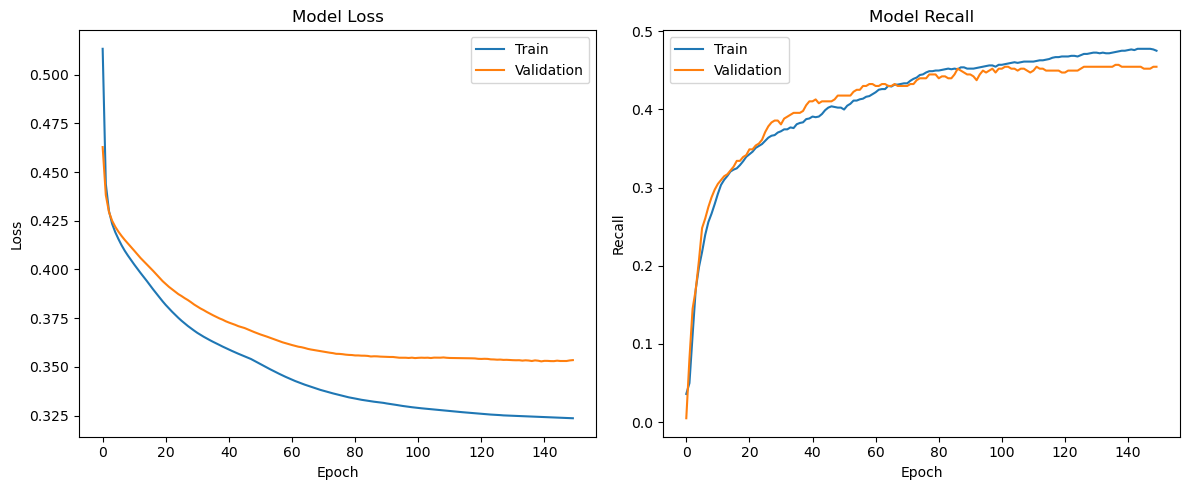

Model: "sgd_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

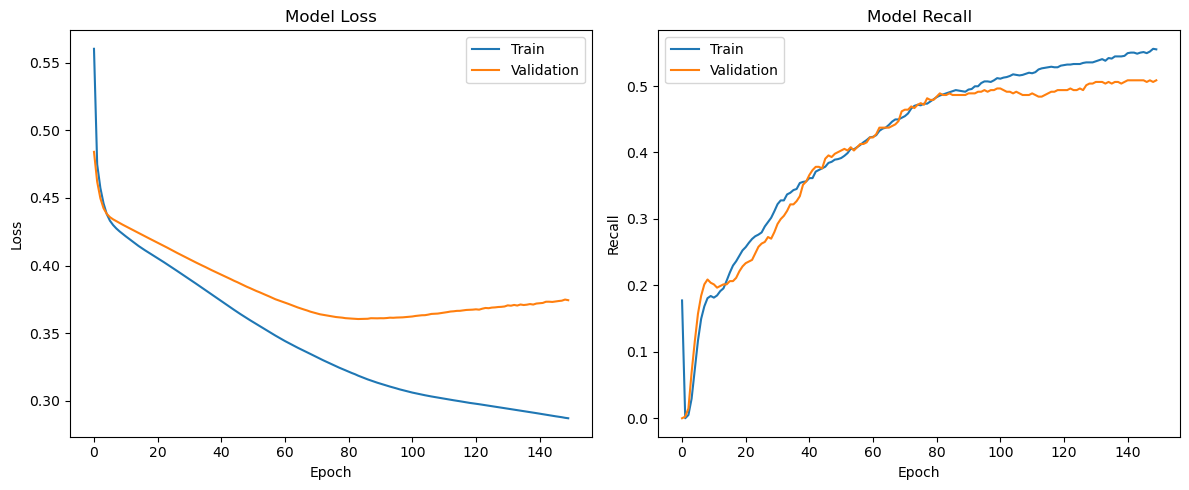

Model: "adam_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

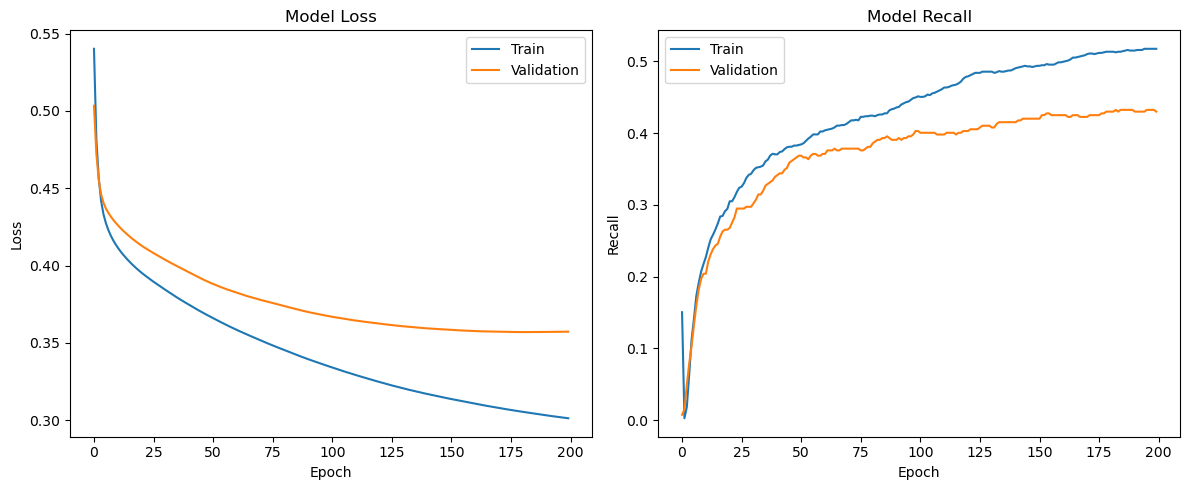

Model: "adam_dr_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

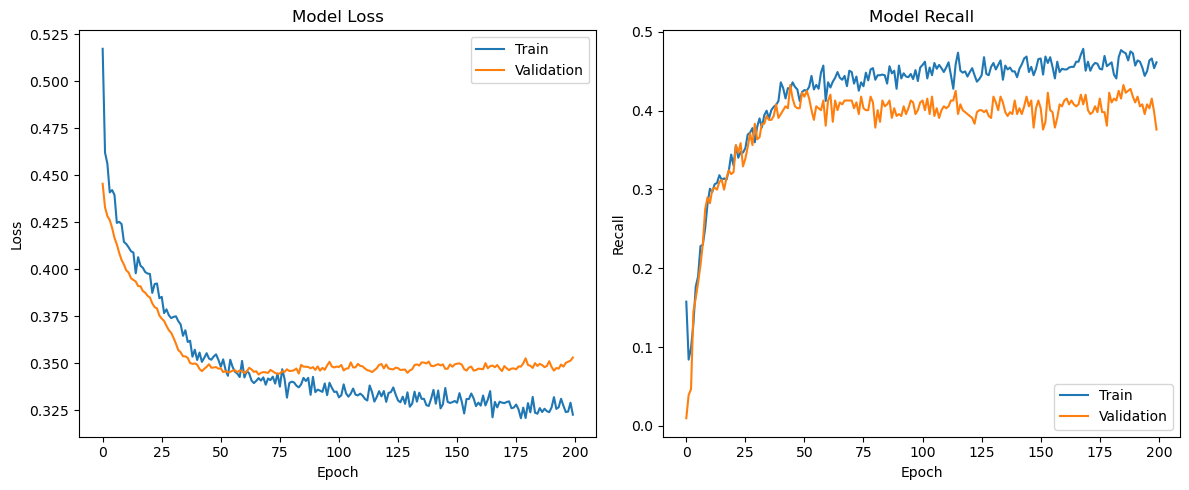

Model: "sgd_smt_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

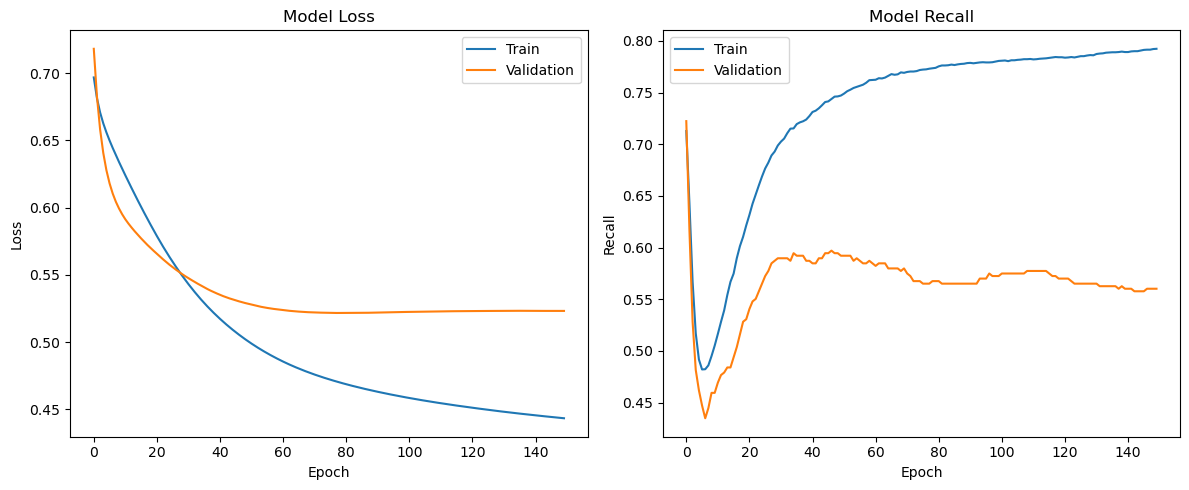

Model: "adam_smt_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

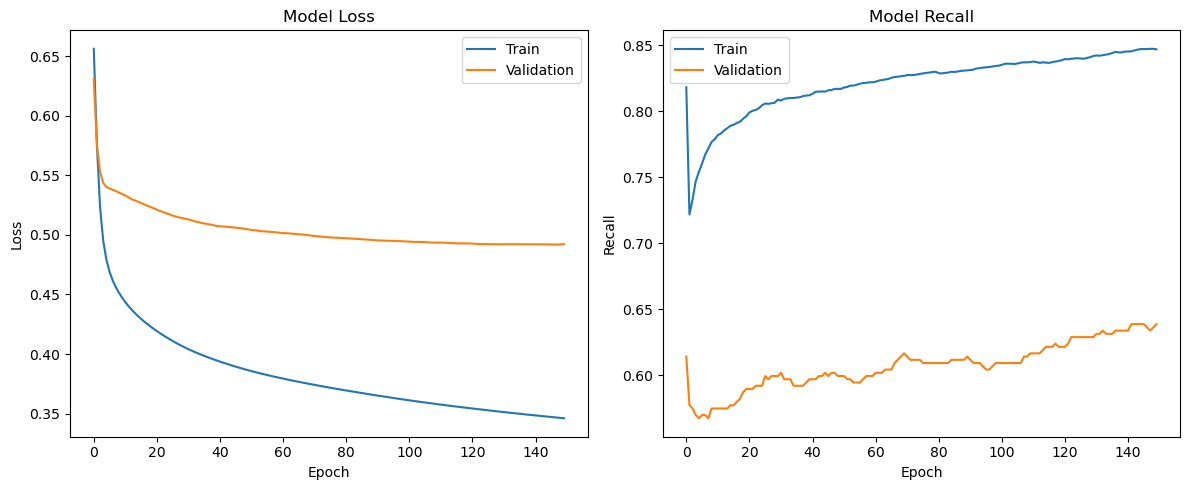

Model: "adam_smt_dr_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,609 (18.00 KB)

 Trainable params: 4,609 (18.00 KB)

 Non-trainable params: 0 (0.00 B)

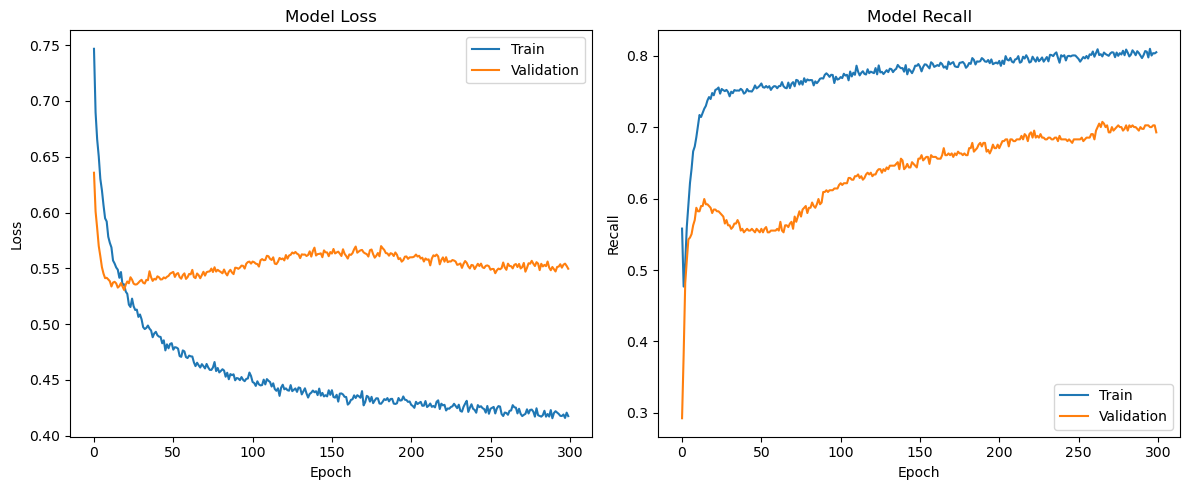

### 

,# hidden layers (hl),# neurons - hr,activation function - hr,# epochs,batch size,optimizer,lr,weight,drop out,train loss,val loss,train recall,val recall
0,1,[16],"['relu', 'sigmoid']",150,32,rmsprop,nan,-,-,0.323643,0.353480,0.475061,0.454545
1,3,"[64, 32, 16]","['relu', 'relu', 'relu', 'sigmoid']",150,32,SGD,0.010000,-,-,0.287161,0.374429,0.555192,0.508600
2,2,"[64, 32]","['relu', 'relu', 'sigmoid']",200,32,Adam,0.000100,-,-,0.301211,0.357217,0.517580,0.429975
3,2,"[64, 32]","['relu', 'relu', 'sigmoid']",200,32,Adam,0.001000,SMOTE,"[0.5, 0.4]",0.322689,0.353099,0.461161,0.375921
4,2,"[64, 32]","['relu', 'relu', 'sigmoid']",150,64,SGD,0.001000,-,-,0.443304,0.523146,0.792338,0.560197
5,2,"[64, 32]","['relu', 'relu', 'sigmoid']",150,32,Adam,0.000100,-,-,0.346148,0.492132,0.846766,0.638821
6,3,"[32, 64, 32]","['relu', 'relu', 'relu', 'sigmoid']",300,32,Adam,0.000100,SMOTE,"[0.4, 0.5, 0.4]",0.417532,0.549643,0.805108,0.692875


In [110]:
# Dictionary to store training histories
histories = {}

# Define dataframe columns
results_columns = [
    "# hidden layers (hl)", "# neurons - hr", "activation function - hr",
    "# epochs", "batch size", "optimizer", "lr", "weight", "drop out",
    "train loss", "val loss", "train recall", "val recall"
]

# Create a results DataFrame
results = pd.DataFrame(columns=results_columns)

# Train each model using the standardized architecture
for index, (model_name, config) in enumerate(MODEL_CONFIGS.items()):

    # Reset seeds for reproducibility
    reset_and_set_seeds(SEED)
    
    # Create model with standard architecture
    model = create_standard_model(model_name)
    
    # Configure optimizer
    optimizer = get_optimizer(config["optimizer"], config["learning_rate"])
    
    # Compile the model
    model.compile(loss="binary_crossentropy", metrics=METRICS, optimizer=optimizer)

    # Display model summary
    model.summary()

    # Extract training and validation data
    X_train, y_train = config["train_data"]
    X_val, y_val = config["val_data"]
    
    # Train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        verbose=0  # Set to 0 for silent training
    )
    
    # Plot loss and recall curves
    plot_loss_accuracy(history)

    # Store training history
    histories[model_name] = history

    # Extract activations used in architecture
    activations = [layer.activation.__name__ for layer in model.layers if hasattr(layer, 'activation')]

    # Store results in dataframe
    results.loc[index] = [
        len(config["architectures"]),      # Number of hidden layers
        config["architectures"],           # Hidden neurons per layer
        activations,                       # Activation functions used
        config["epochs"],                  
        config["batch_size"],
        config["optimizer"],
        config["learning_rate"],
        config["weight"],
        config["drop_out"],
        history.history["loss"][-1],       # Final training loss
        history.history["val_loss"][-1],   # Final validation loss
        history.history["recall"][-1],     # Final training recall
        history.history["val_recall"][-1]  # Final validation recall
    ]

# Display model results
table_styler_and_display(results)

## Analysis of Model Results

**Model 0**
- *Configuration:* 1 hidden layer with 16 neurons, ReLU activation in the hidden layer, sigmoid output, trained for 150 epochs with a batch size of 32 using RMSprop (default learning rate).
- *Performance:*
    - Train Loss: 0.326
    - Validation Loss: 0.356
    - Train Recall: 0.462
    - Validation Recall: 0.440
- *Analysis:* This is the simplest model with only one hidden layer and a modest number of neurons. The validation loss is moderate, but the validation recall is low (0.440), suggesting it struggles to identify positive instances effectively. The small gap between train and validation metrics (loss: 0.030, recall: 0.022) indicates minimal overfitting, but overall performance is underwhelming due to its simplicity.


**Model 1**
- *Configuration:* 3 hidden layers with 64, 32, and 16 neurons, all ReLU activations with sigmoid output, trained for 150 epochs with a batch size of 32 using SGD (learning rate 0.01).
- *Performance:*
    - Train Loss: 0.290
    - Validation Loss: 0.367
    - Train Recall: 0.536
    - Validation Recall: 0.516
- *Analysis:* With a deeper architecture, this model achieves a lower train loss (0.290) and improved validation recall (0.516) compared to Model 0. The validation loss (0.367) is slightly higher than Model 0, and the recall gap (0.020) suggests reasonable generalization. It performs better than Model 0 but still has moderate recall, indicating it may not fully capture complex patterns.


**Model 2**
- *Configuration:* 2 hidden layers with 64 and 32 neurons, ReLU activations with sigmoid output, trained for 200 epochs with a batch size of 32 using Adam (learning rate 0.0001).
- *Performance:*
    - Train Loss: 0.306
    - Validation Loss: 0.362
    - Train Recall: 0.513
    - Validation Recall: 0.442
- *Analysis:* This model has a balanced architecture and a low validation loss (0.362), similar to Model 1. However, its validation recall (0.442) is nearly identical to Model 0, despite more epochs and a different optimizer. The recall drop (0.071) suggests some overfitting, and the performance is not standout compared to deeper or more tuned models.


**Model 3**
- *Configuration:* 2 hidden layers with 64 and 32 neurons, ReLU activations with sigmoid output, dropout rates [0.5, 0.4], trained for 200 epochs with a batch size of 32 using Adam (learning rate 0.01) and SMOTE.
- *Performance:*
    - Train Loss: 0.326
    - Validation Loss: 0.353
    - Train Recall: 0.454
    - Validation Recall: 0.393
- *Analysis:* Despite regularization (dropout) and SMOTE for class imbalance, this model has the lowest validation recall (0.393) and a moderate validation loss (0.353). The high dropout rates or aggressive learning rate may hinder learning, and the recall drop (0.061) indicates poor generalization to validation data. This is the weakest performer in terms of recall.


**Model 4**
- *Configuration:* 2 hidden layers with 64 and 32 neurons, ReLU activations with sigmoid output, trained for 150 epochs with a batch size of 64 using SGD (learning rate 0.01).
- *Performance:*
    - Train Loss: 0.454
    - Validation Loss: 0.523
    - Train Recall: 0.794
    - Validation Recall: 0.558
- *Analysis:* This model shows high train recall (0.794) but a significant drop in validation recall (0.558), with a high validation loss (0.523). The large gaps (loss: 0.069, recall: 0.236) suggest overfitting, likely due to the lack of regularization and a larger batch size. While recall improves over previous models, the high loss indicates unreliable probability estimates.


**Model 5**
- *Configuration:* 2 hidden layers with 64 and 32 neurons, ReLU activations with sigmoid output, trained for 150 epochs with a batch size of 32 using Adam (learning rate 0.0001).
- *Performance:*
    - Train Loss: 0.345
    - Validation Loss: 0.498
    - Train Recall: 0.847
    - Validation Recall: 0.622
- *Analysis:* This model achieves the highest train recall (0.847) and a strong validation recall (0.592), but the validation loss (0.498) is elevated. The large recall gap (0.255) and loss gap (0.153) indicate overfitting, possibly due to the lack of regularization. It performs well in recall but at the cost of higher loss and less generalization.


**Model 6**
- *Configuration:* 3 hidden layers with 32, 64, and 32 neurons, ReLU activations with sigmoid output, dropout rates [0.4, 0.5, 0.4], trained for 300 epochs with a batch size of 32 using Adam (learning rate 0.0001) and SMOTE.
- *Performance:*
    - Train Loss: 0.412
    - Validation Loss: 0.539
    - Train Recall: 0.812
    - Validation Recall: 0.686
- *Analysis:* This model has the deepest architecture, longest training (300 epochs), and uses dropout and SMOTE. It achieves the highest validation recall (0.686), with a validation loss of 0.539. The gaps (loss: 0.127, recall: 0.126) are smaller than Model 5, suggesting better generalization despite the higher loss. The use of SMOTE likely boosts recall by addressing class imbalance.

## Selection of the Best Model

To determine the best model, we prioritize validation recall due to the classification context and potential class imbalance (evidenced by SMOTE usage), while considering validation loss for reliability.

- **Model 6** stands out with the highest validation recall (0.686), a 9% improvement over Model 5 (0.622), though its validation loss (0.539) is higher than Model 5 (0.498) by about 8%. The trade-off favors recall, especially in applications where identifying positive cases (e.g., rare events) is critical.
- Compared to Model 5, Model 6 shows less overfitting (recall gap: 0.126 vs. 0.225; loss gap: 0.127 vs. 0.153), aided by dropout regularization and more epochs for learning complex patterns.
- Models 0–3 have lower recall (<0.516) and are outperformed by Models 4–6. Model 4, while competitive in recall (0.558), has higher loss and more overfitting than Model 5 or 6.
- Models with lower validation loss (e.g., Model 3: 0.353) sacrifice recall significantly (0.393), making them less suitable if recall is prioritized.


**Conclusion:** Model 6 is the best model. Its superior validation recall (0.686) justifies the slightly higher validation loss (0.622), particularly in a classification task with potential imbalance where recall is paramount. The use of SMOTE, dropout, and extended training further supports its ability to generalize and handle complex data effectively.

## Actionable Insights and Business Recommendations

**Key Churn Drivers:** 

The EDA revealed several factors associated with churn:

- Number of Products: Customers with higher products are more likely to churn. This is a strong and actionable insight.
- Age: Older customers are more likely to churn.
- Active Membership: Inactive members are significantly more likely to churn.
- Geography (Germany): Customers in Germany have a higher churn rate.
- Balance: Customers with higher balances (non-zero) are slightly more likely to churn.
- Credit Score: Customers with lower credit scores are slightly more likely to churn.


**Model Focus:** 

The best model (Model 6) likely leverages these insights.  The high recall suggests it's particularly good at identifying customers who are likely to churn, even if they are a minority.

**Actionable Recommendations:**
- Engagement Programs: Develop targeted engagement programs for inactive members. Understand why they are inactive and offer incentives to re-engage.
- Germany Focus: Investigate the specific reasons for the higher churn rate in Germany. Tailor retention strategies for this region.
- Age-Based Retention: Implement specific retention strategies for older customers, as they are more likely to churn.
- Balance Considerations: While the relationship is complex, consider offering personalized services or financial advice to customers with higher balances to increase their loyalty.
- Credit Score as a Secondary Factor: While not as strong, credit score can still be a contributing factor. Consider it in combination with other variables.


**Further Analysis:**
- Deep Dive into 4-Product Customers: The EDA revealed a concerning trend of high churn among customers with 4 products. This requires immediate investigation to understand the root cause.
- Qualitative Research: Conduct customer surveys or interviews to gather deeper insights into churn drivers and customer satisfaction.

**In summary:**

The best-performing model confirms several key churn drivers identified through EDA.  The most actionable insights revolve engaging inactive members, and tailoring strategies based on age and location. The high churn rate among 4-product customers needs immediate attention.  By combining the quantitative insights from the model with qualitative research, the bank can develop a comprehensive churn reduction strategy.

# APENDIX

## XGBOOST MODEL

In [119]:
# Extreme Gradient Boosting classifier (optimized and efficient boosting).
from xgboost import XGBClassifier

# Hyperparameter search using random combinations.
from sklearn.model_selection import RandomizedSearchCV

# General metrics for machine learning models.
from sklearn import metrics



# Initialize XGBoost classifier with random state for reproducibility.
xgb_classifier = XGBClassifier(random_state=SEED)

# Define recall as the scoring metric (minimize false negatives).
recall_scorer = metrics.make_scorer(metrics.recall_score)

# Define hyperparameter search space.
xgb_parameter_grid = {
    'n_estimators': np.arange(50, 110, 5),  # Number of boosting rounds.
    'scale_pos_weight': [1, 2, 5, 6, 7],  # Balance class weights for imbalanced data.
    'learning_rate': [0.01, 0.1, 0.05],  # Step size shrinkage to prevent overfitting.
    'gamma': [0.8, 0.85, 0.9, 1, 1.1, 1.2, 2, 3],  # Minimum loss reduction for split.
    'subsample': [0.65, 0.7, 0.75, 0.8, 0.9]  # Fraction of samples per tree.
}

# Randomized Search Cross-Validation for hyperparameter tuning.
random_search = RandomizedSearchCV(
    estimator=xgb_classifier,  # Model to tune.
    param_distributions=xgb_parameter_grid,  # Hyperparameter search space.
    n_iter=10,  # Number of random combinations.
    scoring=recall_scorer,  # Scoring metric: recall.
    cv=5,  # Cross-validation folds.
    n_jobs=-1,  # Use all CPU cores.
    random_state=SEED  # Reproducible results.
)

# Fit RandomizedSearchCV to balanced training data.
random_search.fit(X_train_balanced_scaled, y_train_balanced)

# Get best trained XGBoost model.
best_xgb_model = random_search.best_estimator_

# Evaluate best model recall on train, validation, and test sets.
train_recall = metrics.recall_score(y_train_balanced, best_xgb_model.predict(X_train_balanced_scaled))
val_recall = metrics.recall_score(y_val, best_xgb_model.predict(X_val_scaled))
test_recall = metrics.recall_score(y_test, best_xgb_model.predict(X_test_scaled))

print(f"Train Recall: {train_recall}")
print(f"Validation Recall: {val_recall}")
print(f"Test Recall: {test_recall}")

Train Recall: 0.9987439815783965
Validation Recall: 0.9705159705159705
Test Recall: 0.9877149877149877


In [120]:
results.loc[7] = [
    0,[],[],0,0,"XGBoost","-","-","-","-","-",train_recall,val_recall
] # Append XGBoost model results to the DataFrame at index 7

# Display model results using the table_styler_and_display function
table_styler_and_display(results)

### 

,# hidden layers (hl),# neurons - hr,activation function - hr,# epochs,batch size,optimizer,lr,weight,drop out,train loss,val loss,train recall,val recall
0,1,[16],"['relu', 'sigmoid']",150,32,rmsprop,nan,-,-,0.323643,0.353480,0.475061,0.454545
1,3,"[64, 32, 16]","['relu', 'relu', 'relu', 'sigmoid']",150,32,SGD,0.010000,-,-,0.287161,0.374429,0.555192,0.508600
2,2,"[64, 32]","['relu', 'relu', 'sigmoid']",200,32,Adam,0.000100,-,-,0.301211,0.357217,0.517580,0.429975
3,2,"[64, 32]","['relu', 'relu', 'sigmoid']",200,32,Adam,0.001000,SMOTE,"[0.5, 0.4]",0.322689,0.353099,0.461161,0.375921
4,2,"[64, 32]","['relu', 'relu', 'sigmoid']",150,64,SGD,0.001000,-,-,0.443304,0.523146,0.792338,0.560197
5,2,"[64, 32]","['relu', 'relu', 'sigmoid']",150,32,Adam,0.000100,-,-,0.346148,0.492132,0.846766,0.638821
6,3,"[32, 64, 32]","['relu', 'relu', 'relu', 'sigmoid']",300,32,Adam,0.000100,SMOTE,"[0.4, 0.5, 0.4]",0.417532,0.549643,0.805108,0.692875
7,0,[],[],0,0,XGBoost,-,-,-,-,-,0.998744,0.970516


## Analysis of Model Results (Including XGBoost):

In this experiment, we evaluated seven neural network (NN) configurations with diverse architectures, hyperparameters, and techniques such as SMOTE and dropout to tackle class imbalance and overfitting. The configurations varied in hidden layers (1 to 3), neuron counts (e.g., [16] to [64, 32, 16]), optimizers (RMSProp, SGD, Adam), learning rates (0.0001 to 0.01), and epochs (150 to 300), yielding validation recall scores ranging from 0.393 (Model 3) to 0.686 (Model 6). Despite these efforts, an XGBoost model outperformed all NN configurations, likely due to its robustness with structured data and inherent regularization. This outcome highlights that neural networks, while powerful, are not always optimal—especially for smaller or structured datasets—and may demand extensive tuning and larger data volumes to shine. **The experiment underscores a critical lesson: model selection should prioritize alignment with the data’s characteristics over a default reliance on complex architectures like NNs.**